Cross check with scripts

In [121]:

def add_vol(h_name, subset, name = "vol_m3"):
    """
    add hypsometry...
    """
    for i, ind in enumerate(subset[h_name].dropna().index):
        diff = (subset.loc[ind][h_name] - hypso.h_m).dropna().abs()
        subset.at[ind, name] = hypso.iloc[diff.idxmin()].vol_m3
    return subset



In [122]:
# import matplotlib
# import matplotlib.pyplot as plt

# import pandas as pd
# from pandas.plotting import register_matplotlib_converters
# import numpy as np
# import hydrofunctions as hf

# register_matplotlib_converters()
# plt.style.use('ggplot')

# import sys
# sys.path.append('/Users/octaviacrompton/Google_Drive_quatratavia/estuaries_jenner/scripts/')
# sys.path.append("drive/MyDrive/estuaries_Jenner/scripts/")


# %matplotlib inline
# hf.__version__
# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 300

In [123]:
# plt.rcParams['figure.figsize'] = (12.0, 6.0)
# for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
#     if mod in sys.modules:
#         del sys.modules[mod]

# import plot_config
# from timeseries_functions import *
# from seepage_analysis import *
# from seepage_plots import *

# mpl.rcParams['figure.dpi'] = 300

# root = '/Users/octaviacrompton/Google_Drive_quatratavia/estuaries_jenner/'

In [124]:
# # --- IPython autoreload (no-op in plain Python) ---
# try:
#     from IPython import get_ipython
#     ip = get_ipython()
#     if ip is not None:
#         ip.run_line_magic("load_ext", "autoreload")
#         ip.run_line_magic("autoreload", "2")   # reload all modules (except those excluded)
# except Exception:
#     pass

# # --- paths (root = this file/notebook folder) ---
# from pathlib import Path
# import sys, importlib
# try:
#     here = Path(__file__).resolve().parent
# except NameError:
#     here = Path.cwd().resolve()
# root    = here
# scripts = root / "scripts"
# if str(scripts) not in sys.path:
#     sys.path.insert(0, str(scripts))
    
#     import seaborn as sns
# import pandas as pd
# import matplotlib.pylab as plt

# # std libs
# from pathlib import Path
# import sys, importlib

# # plotting
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# plt.style.use("ggplot")
# mpl.rcParams.update({"figure.dpi": 300, "figure.figsize": (12, 6)})


# from matplotlib.ticker import MaxNLocator
# import matplotlib.dates as mdates
# from matplotlib.dates import DateFormatter


# mpl.rcParams['figure.dpi'] = 300

# # paths: root = this file/notebook folder
# try:
#     here = Path(__file__).resolve().parent   # .py files
# except NameError:
#     here = Path.cwd().resolve()              # notebooks

# root    = here.parent                                
# scripts = root / "scripts"
# if str(scripts) not in sys.path:
#     sys.path.insert(0, str(scripts))          # ensure your modules are found first

# # dev-friendly reload while keeping import *
# def _reload_star(mod_names):
#     importlib.invalidate_caches()
#     for name in mod_names:
#         if name in sys.modules:
#             del sys.modules[name]

# _mods = ["plot_config", "timeseries_functions", "seepage_analysis", "seepage_plots"]
# _reload_star(_mods)

# # keep star-imports as requested
# from plot_config import *
# from timeseries_functions import *
# from seepage_analysis import *
# from seepage_plots import *

# data_path = root / "data"

# hypso = pd.read_excel(data_path / "RR_stage_storage.xlsx", header=3)


In [125]:
# --- IPython autoreload (no-op in plain Python) ---
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# --- std libs & paths (root = this file/notebook folder) ---
from pathlib import Path
import sys

try:
    here = Path(__file__).resolve().parent   # .py files
except NameError:
    here = Path.cwd().resolve()              # notebooks

root    = here.parent                                # ← same location as requested
scripts = root / "scripts"
if str(scripts) not in sys.path:
    sys.path.insert(0, str(scripts))

# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import seaborn as sns

plt.style.use("ggplot")
mpl.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (12, 6),
})

# --- data libs ---
import pandas as pd
import numpy as np

# --- your modules (keep star-imports as requested) ---


import sys
sys.path.append('../src/')

mpl.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (12.0, 6.0)


for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
    if mod in sys.modules:
        del sys.modules[mod]

import plot_config
from timeseries_functions import *
from seepage_analysis import *
from seepage_plots import *



root = '/Users/octaviacrompton/Google_Drive_quatratavia/estuaries_jenner/russian-river-seepage/'

# example path usage
data_path = root +  "data/"
hypso = pd.read_excel(data_path + "RR_stage_storage.xlsx", header=3)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [126]:
# merged = add_power_visitor(merged, 24, label = 'visitor_24_hr' )
# merged = add_power_USGS(merged, 24, label = 'USGS_24_hr' )

# merged.to_pickle("merged.pkl")


In [127]:
merged = pd.read_pickle(data_path + "/processed/merged.pkl")

In [128]:
merged = add_power_visitor(merged, 12, label = 'visitor_12_hr' )
merged = add_power_USGS(merged, 12, label = 'USGS_12_hr' )

merged['State_visit'] = (merged['visitor_12_hr'] < 0.3) & (merged['State'] == 1)
merged['State_USGS'] = (merged['USGS_12_hr'] < 0.3) & (merged['State'] == 1)

merged['State_visit'] = merged['State_visit'].astype(float)
merged['State_USGS'] = merged['State_USGS'].astype(float)

(-10.0, 8.0)

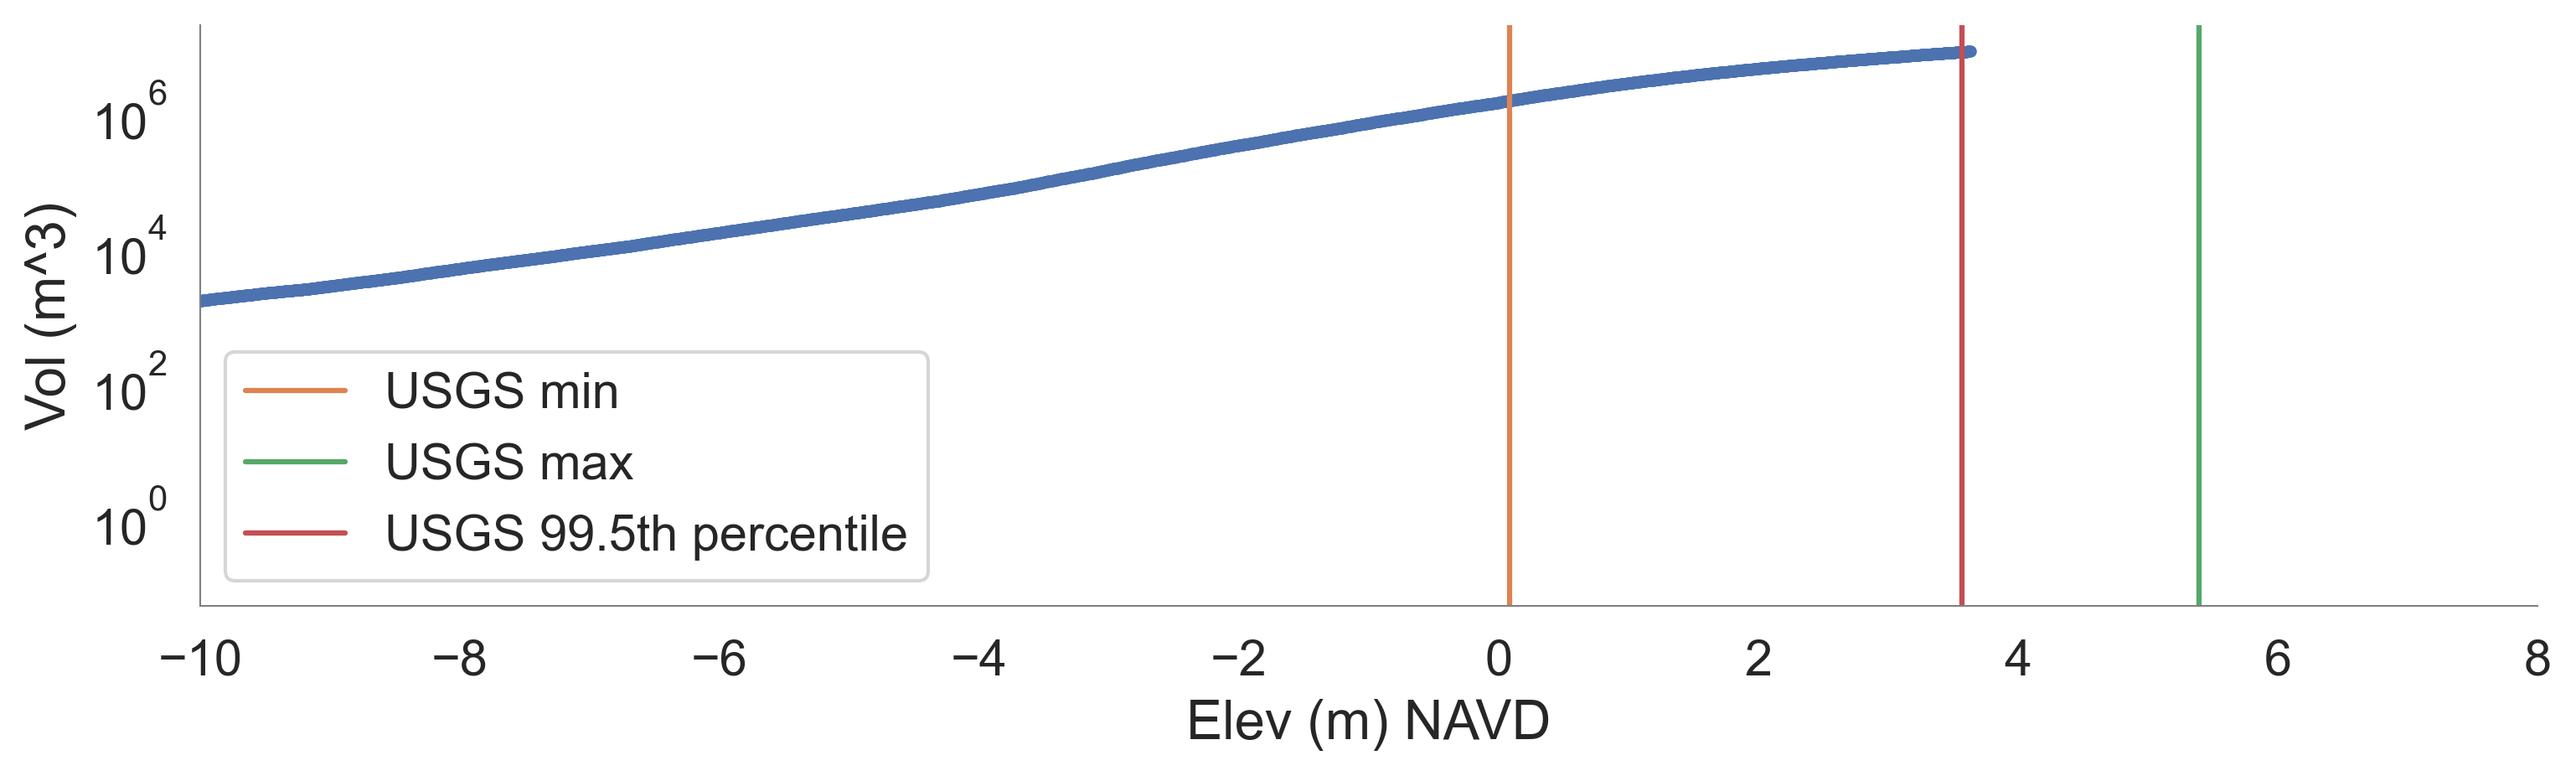

In [129]:


hypso.columns = ['h_m', 'vol_m3', 'A_m2']
hypso['h_m'] = hypso['h_m'] + 2.73*0.3048

hypso.head()

hypso['vol_m3'].max()/ hypso['h_m'].max()
# 2235803.62 m2, 223 km2

### Hypso plots

plt.figure(figsize = (12, 3))
ax = plt.gca()
ax.plot(hypso.h_m, hypso.vol_m3, '.', ms = 5)
ax.set_ylabel("Vol (m^3)")
ax.set_xlabel("Elev (m) NAVD")
ax.set_yscale("log")
plt.axvline(merged.USGS_h.min(),  c = 'C1', label = "USGS min")
plt.axvline(merged.USGS_h.max(), c = 'C2', label = "USGS max")
plt.axvline(np.percentile(merged.USGS_h.dropna(), 99.5), c = 'C3', label = "USGS 99.5th percentile")
ax.legend()
ax.set_xlim(-10, 8)

(-10.0, 8.0)

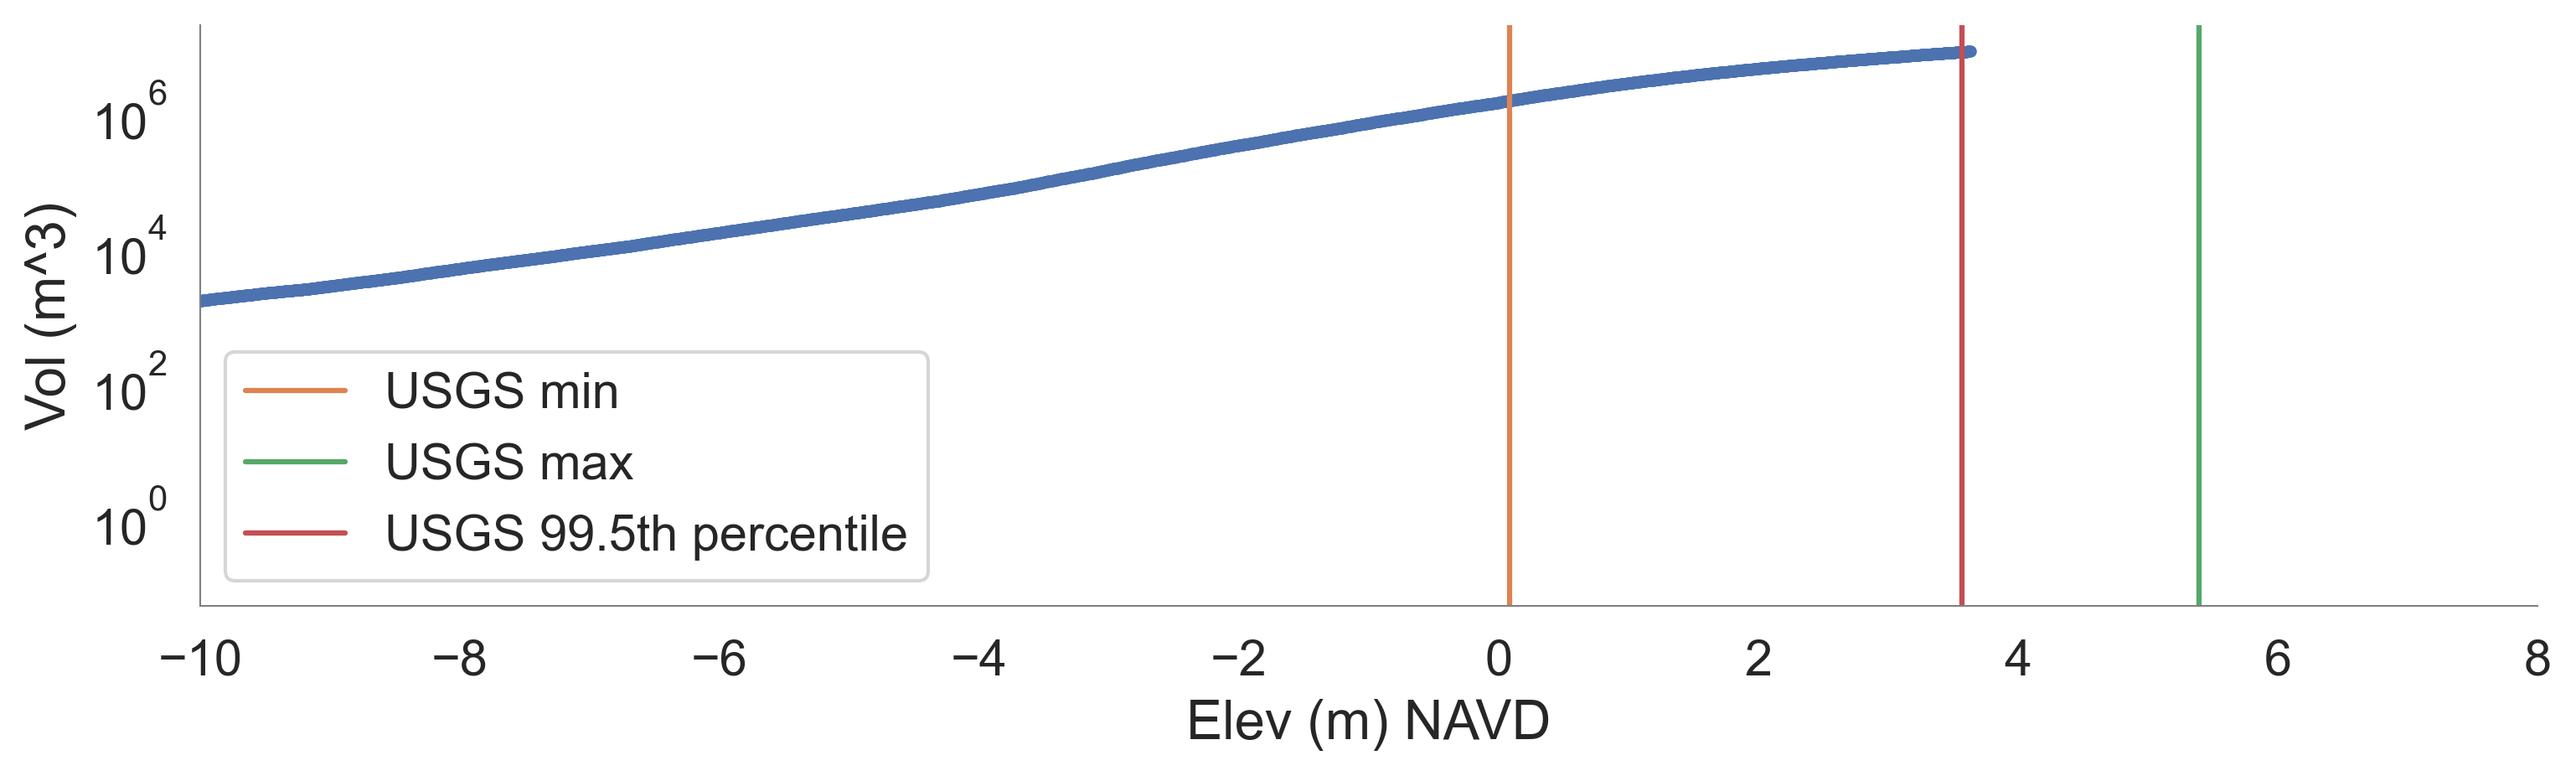

In [130]:
plt.figure(figsize = (12, 3))
ax = plt.gca()
ax.plot(hypso.h_m, hypso.vol_m3, '.', ms = 5)
ax.set_ylabel("Vol (m^3)")
ax.set_xlabel("Elev (m) NAVD")
ax.set_yscale("log")
plt.axvline(merged.USGS_h.min(),  c = 'C1', label = "USGS min")
plt.axvline(merged.USGS_h.max(), c = 'C2', label = "USGS max")
plt.axvline(np.percentile(merged.USGS_h.dropna(), 99.5), c = 'C3', label = "USGS 99.5th percentile")
ax.legend()
ax.set_xlim(-10, 8)

In [131]:
import pandas as pd
import numpy as np

# Assuming hypso is your DataFrame with columns 'h_m' and 'vol_m3'
hypso['A_surface'] = hypso['vol_m3'].diff() / hypso['h_m'].diff()

# Optionally fill first row with 0 or NaN
hypso['A_surface'].iloc[0] = np.nan  # or 0

# Find max surface area
max_surface_area = hypso['A_surface'].max()
max_row = hypso.loc[hypso['A_surface'].idxmax()]

print(f"Max surface area: {max_surface_area:.2f} m² at elevation h = {max_row['h_m']:.2f} m")
# estuary area is about 2.5 square km

Max surface area: 2533116.34 m² at elevation h = 3.62 m


Text(0.5, 0, 'Elev (m) NAVD')

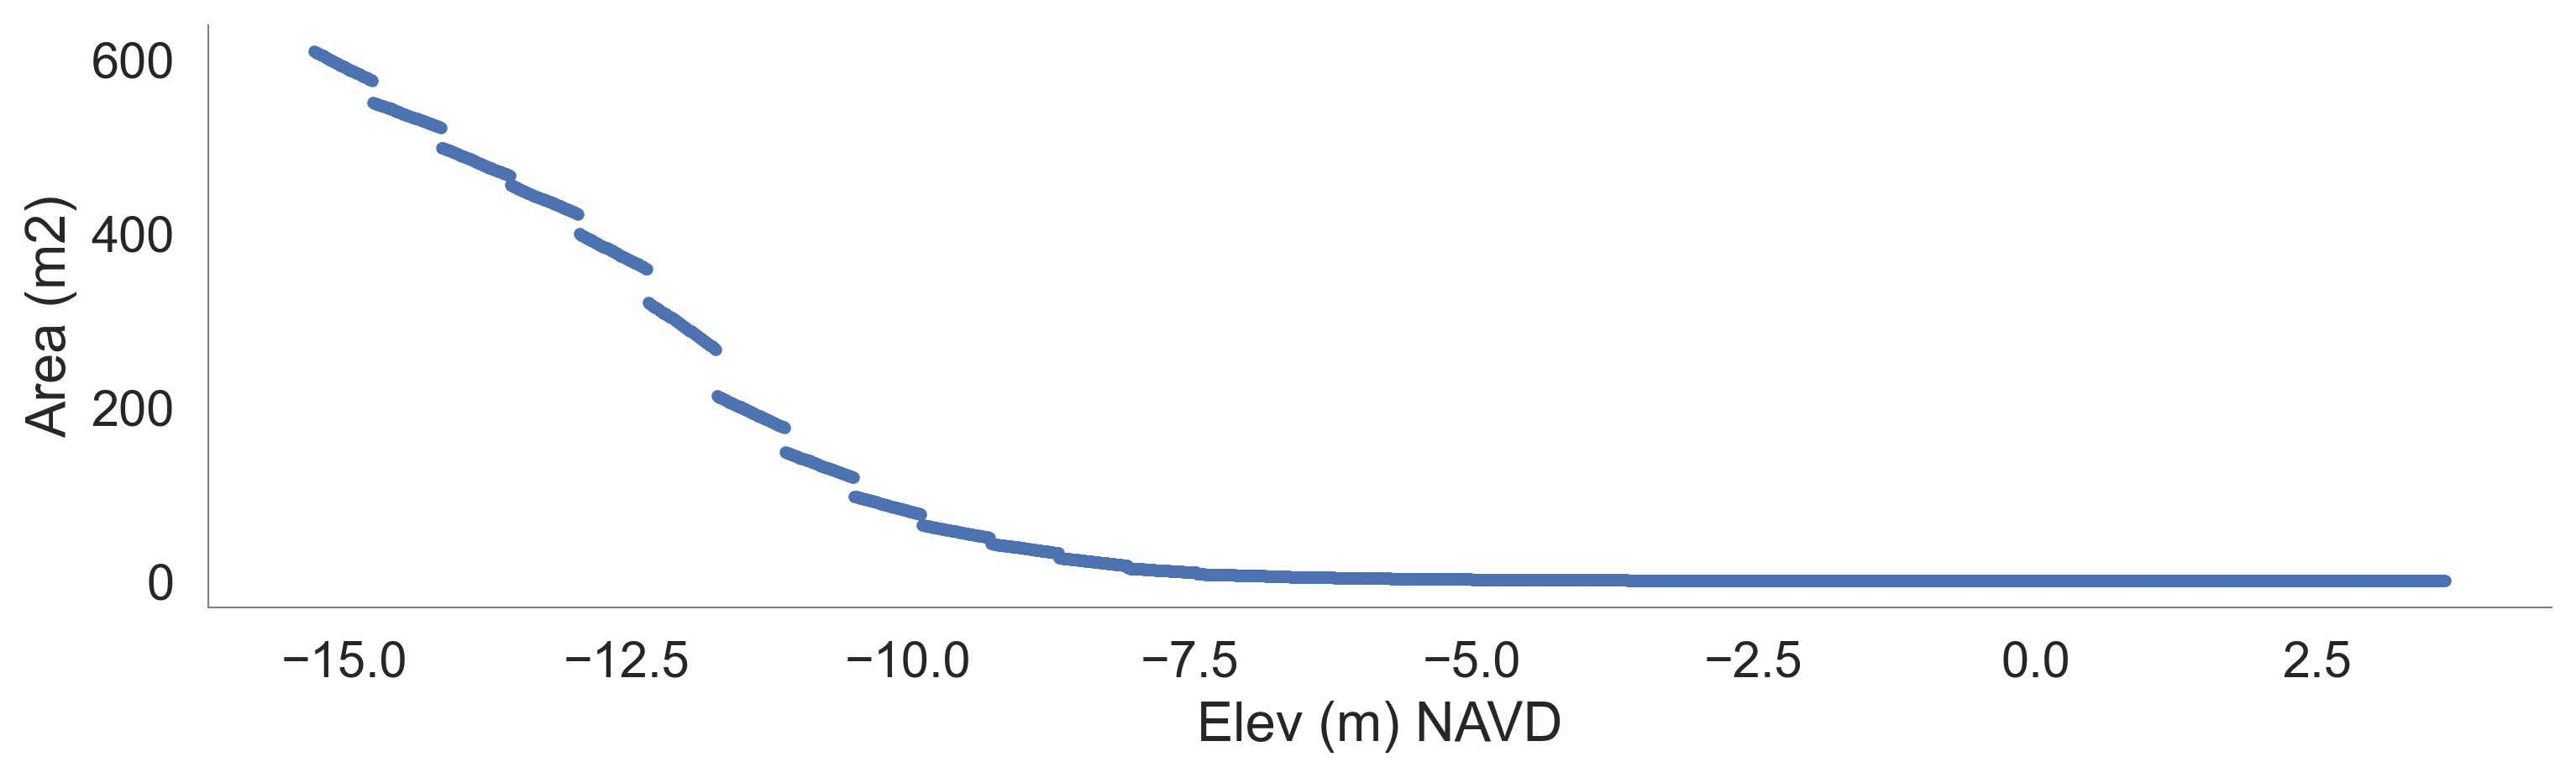

In [132]:
plt.figure(figsize = (12, 3))
plt.plot(hypso.h_m, hypso.A_m2, '.', ms = 5)
plt.ylabel("Area (m2)")
plt.xlabel("Elev (m) NAVD")


## Code to identify closures

In [133]:


patches = find_patches(list(merged.State))

inds = list(patches.keys())

In [134]:
visitor_patches = find_patches(list(merged.State_visit))

visitor_inds = list(visitor_patches.keys())

USGS_patches = find_patches(list(merged.State_USGS))

USGS_inds = list(USGS_patches.keys())

In [135]:
visitor_closures = get_visitor_closures(merged)
closures = get_visitor_closures(merged)


In [136]:
visitor_closures.query("duration >= 10").shape, closures.query("duration > 10").shape


((29, 4), (28, 4))

In [137]:
durations = (np.array(list(patches.values()))/24/4 )

In [138]:
len(durations), sum(durations > 4),  sum(durations > 9),

(107, 63, 30)

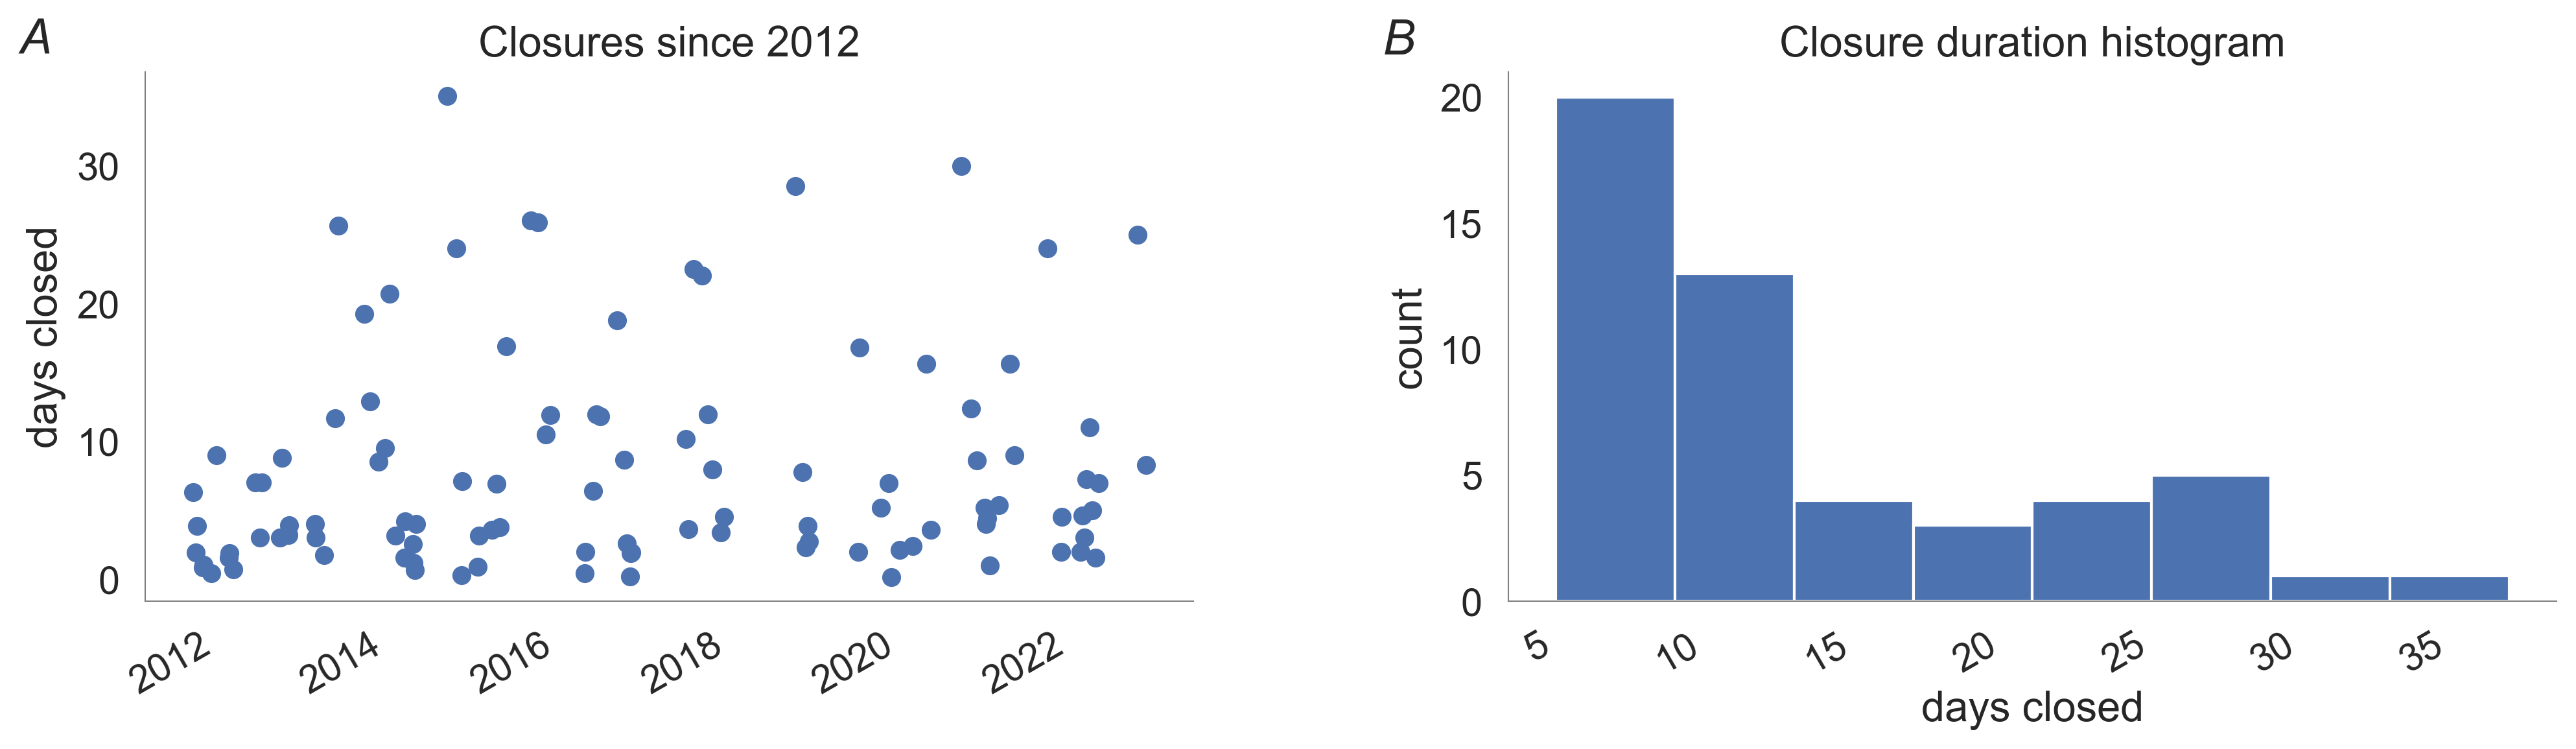

In [139]:
fig, axes = plt.subplots(1, 2, figsize = (16,4))
plt.subplots_adjust(wspace = 0.3)
ax = axes[0]
for key in visitor_patches.keys():
    ax.plot(merged.iloc[key].name.date(), visitor_patches[key]/24/4, 'bo')
plt.gcf().autofmt_xdate()
ax.set_ylabel('days closed')
ax.set_title("Closures since 2012")

ax = axes[1]
ax.hist(np.array(list(visitor_patches.values()))/24/4, np.arange(5, 40, 4))
ax.set_ylabel("count")
ax.set_xlabel("days closed")
ax.set_title("Closure duration histogram")

axes[0].text(-0.12, 1.1, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[1].text(-0.12, 1.1, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

### Fourier transform to detect open/close events


(178, 163)

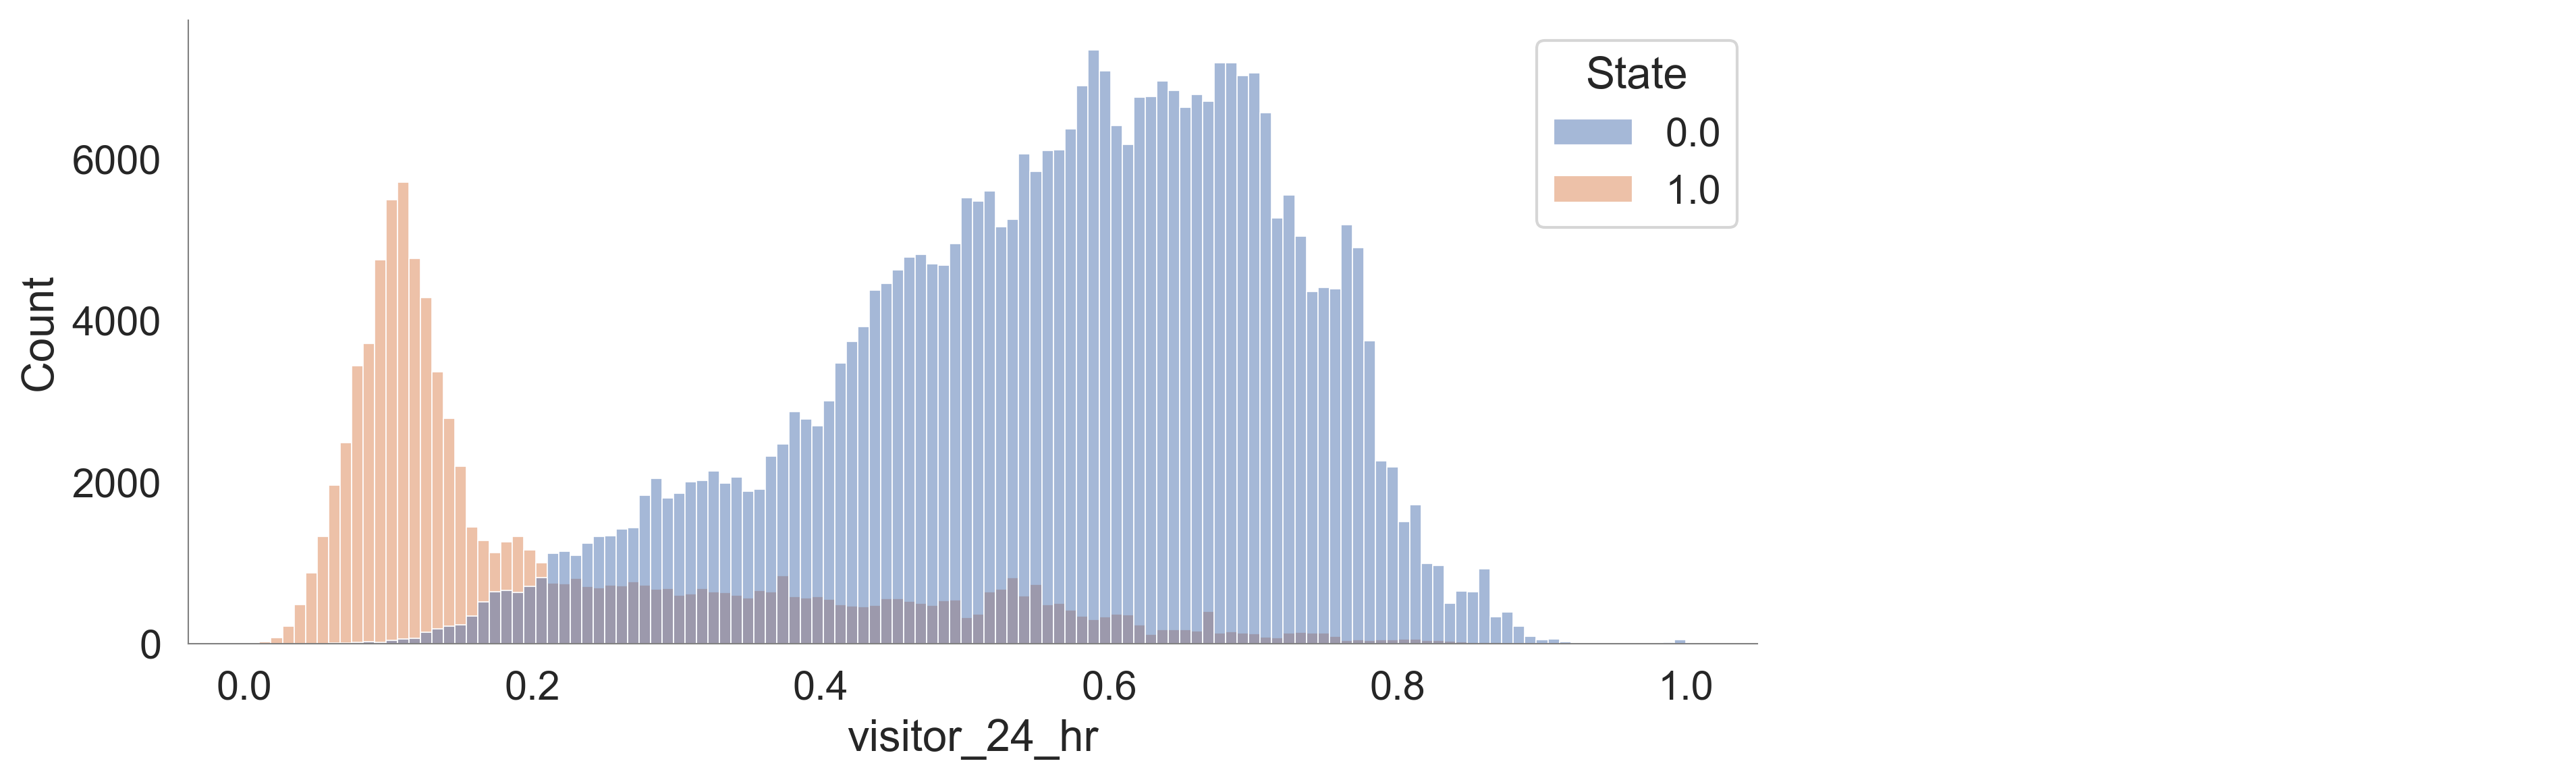

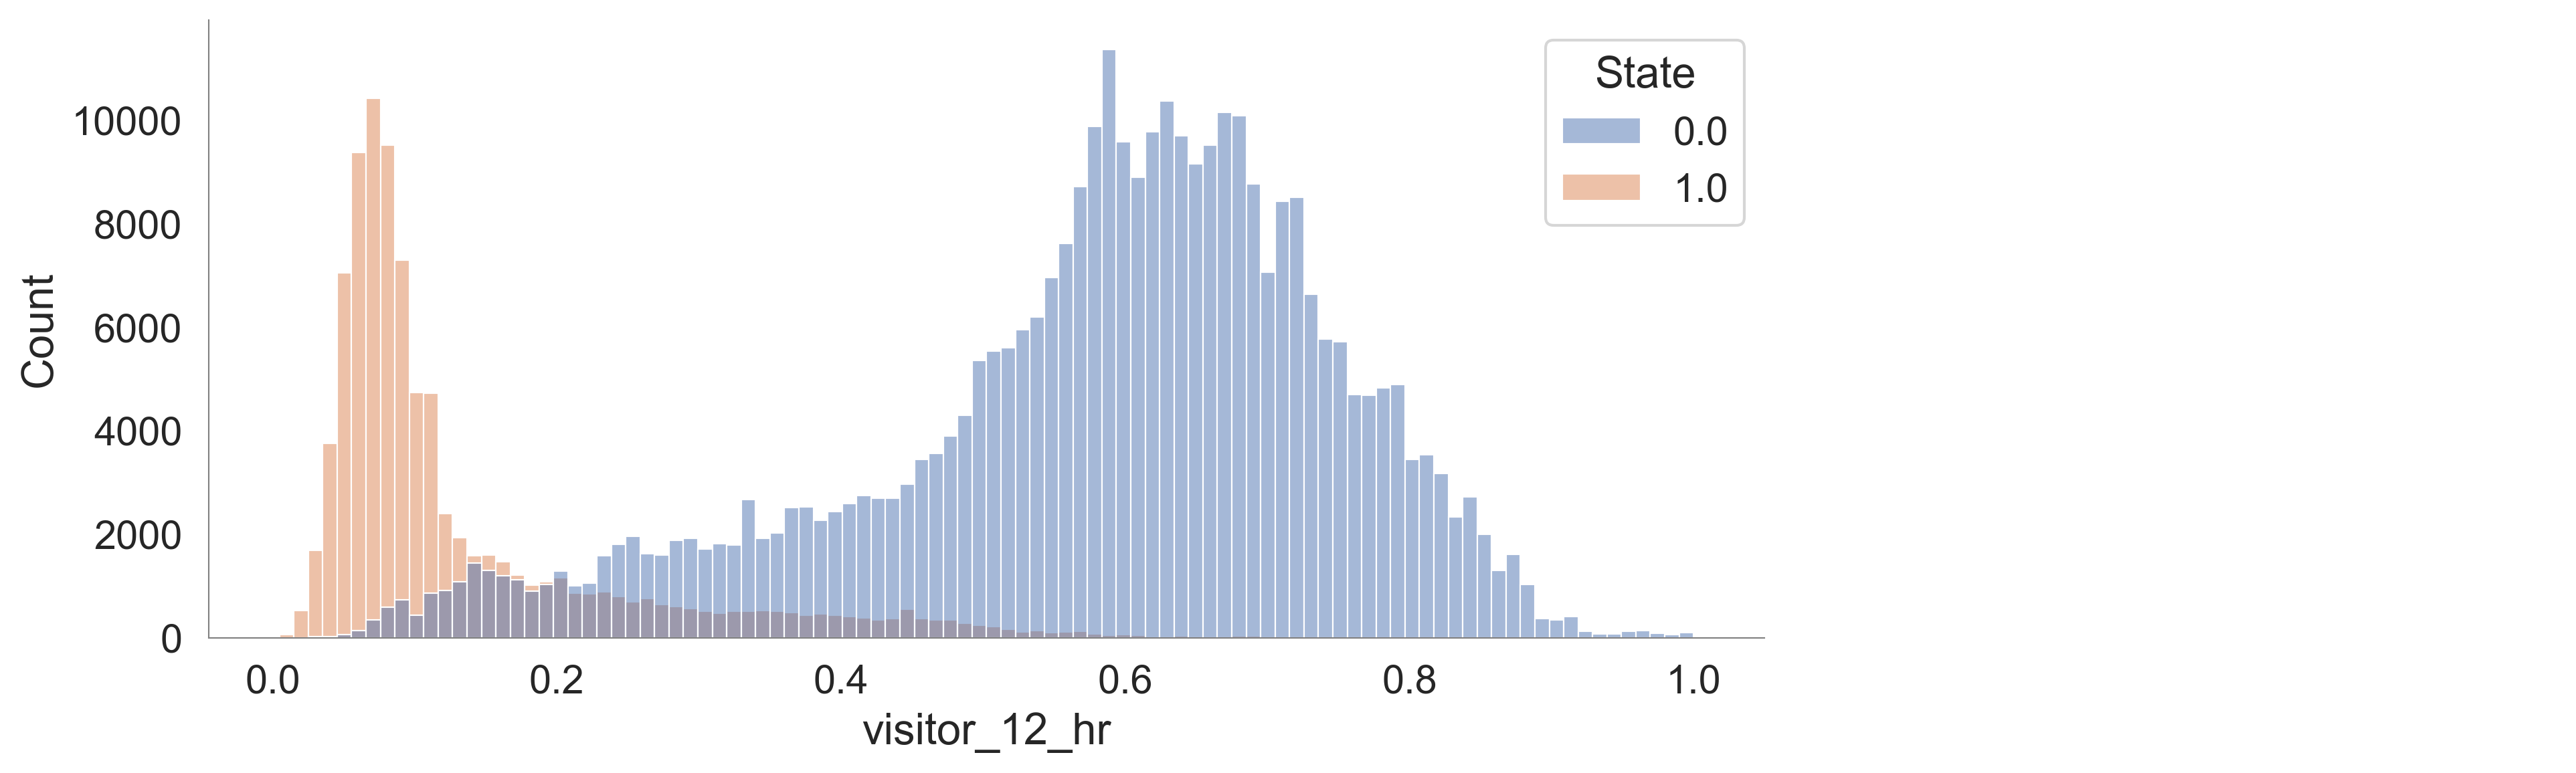

In [140]:
import seaborn as sns
plt.figure(figsize = (10, 4))
sns.histplot(data=merged, x= 'visitor_24_hr', hue='State', alpha = 0.5)

ax = plt.gca()
ax.text(1.5, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
len(np.unique(merged.query("State == 0 and visitor_24_hr < 0.2").index.date))


plt.figure(figsize = (10, 4))
sns.histplot(data=merged, x= 'visitor_12_hr', hue='State', alpha = 0.5)

ax = plt.gca()
ax.text(1.5, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

len(np.unique(merged.query("State == 0 and visitor_12_hr < 0.2").index.date)), \
len(np.unique(merged.query("State == 1 and visitor_12_hr > 0.3").index.date))

## Add wave energy

https://cdip.ucsd.edu/themes/media/docs/documents/html_pages/compendium.html

In [141]:
import xarray as xr

hindcast = xr.open_dataset(data_path + 'CDIP/MOP_alongshore_VE157_hindcast.nc')
nowcast = xr.open_dataset(data_path + 'CDIP/VE157_nowcast.nc')

waveHs = pd.DataFrame({"waveHs" : hindcast.waveHs.data}, index= pd.to_datetime(hindcast.time.data))

waveHs = pd.concat([waveHs, pd.DataFrame({"waveHs" : nowcast.waveHs.data}, index= pd.to_datetime(nowcast.waveTime))], axis = 0)

waveHs.index = waveHs.index.tz_localize("UCT")

hourly = merged.groupby(pd.Grouper(freq='H'))[['State_visit', 'State_USGS', 'USGS_h', 'visitor_h','v',
                                               'Q', 'visitor_12_hr']].median()
hourly.index = pd.to_datetime(hourly.index)
hourly = hourly.join(waveHs, how = 'inner')

merged['date_hr']  = merged.index.round('H')
merged['datetime']  = merged.index
waveHs['date_hr'] = waveHs.index


merget_no_wave = merged.copy()
merged_wave = merged.merge(waveHs, on = 'date_hr', how = 'inner')
merged_wave.index = merged_wave.datetime
# merged_wave = merged_wave.drop('datetime', axis = 1)

In [142]:
# merged_all = merged.copy()
merged_wave.query("waveHs > 0.5").shape[0]/ merged_wave.shape[0]

0.15328716278672905

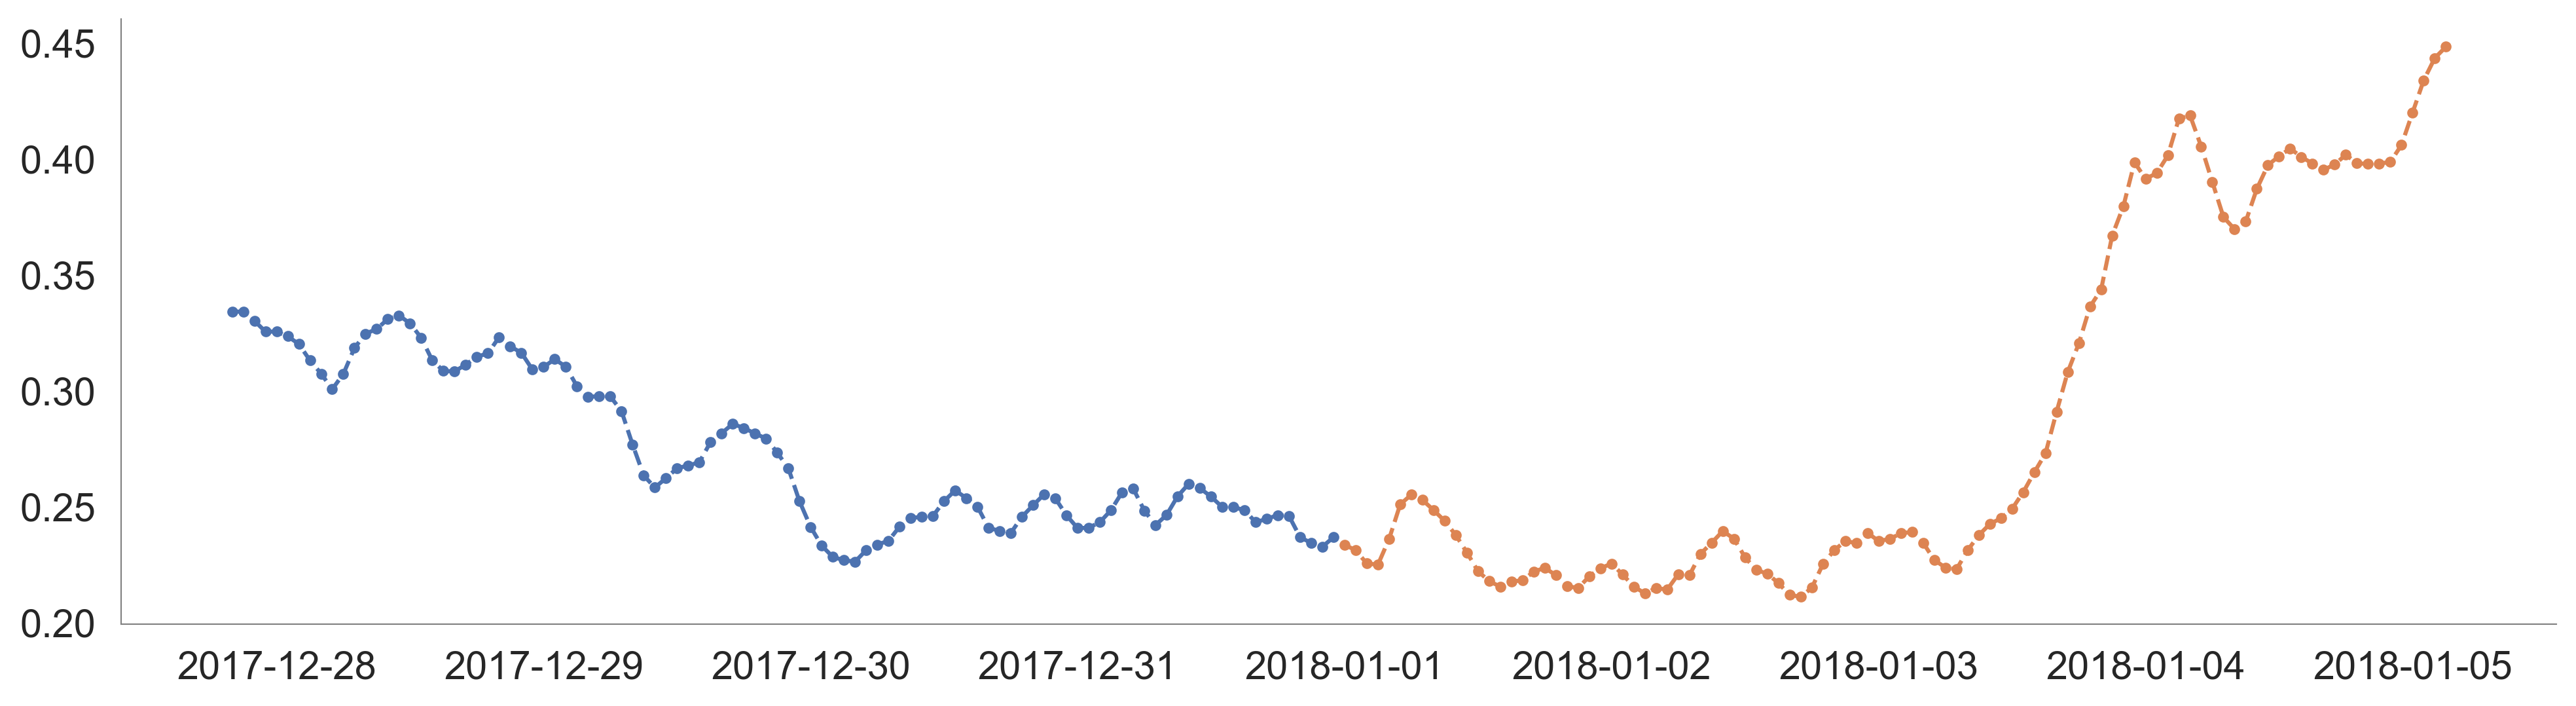

In [143]:
plt.figure(figsize = (16, 4))
plt.plot(hindcast.time.data[-100:], hindcast.waveHs.data[-100:], '.--')
plt.plot(nowcast.waveTime.data[:100], nowcast.waveHs.data[:100], '.--')

## Wind


In [144]:
import os
files = os.listdir(data_path + 'bml_wind')

In [145]:
wind = pd.DataFrame()
for file in files:
    wind = pd.concat([wind,
                      pd.read_csv(data_path + 'bml_wind/{0}'.format(file), header = None,
                                  names = ['date', 'blank',  'wind'])])

In [146]:
wind = wind.query("date != 'UTC_Datetime'")
wind['date_hr'] = pd.to_datetime(wind.date,utc = True)
wind = wind.drop(['blank', 'date'], axis = 1)

In [147]:
merged_wave = merged_wave.merge(wind, on = 'date_hr', how = 'inner')
merged_wave.index = merged_wave.datetime
# merged_wave = merged_wave.drop('datetime', axis = 1)

In [148]:
merged_wave.shape, merged.shape

((395882, 24), (421943, 22))

## Hourly analysis

In [149]:
# plt.rcParams['figure.figsize'] = (12.0, 6.0)
# for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
#     if mod in sys.modules:
#         del sys.modules[mod]

# import plot_config
# from timeseries_functions import *
# from seepage_analysis import *
# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 300

# root = '/Users/octaviacrompton/Google_Drive_quatratavia/estuaries_jenner/'

In [150]:


ind = 0
subset = get_subset(merged, ind, 0, 0)
hourly_subset = get_hourly_visitor(subset)


In [151]:
# ind = hourly_subset['vol_p_1day'][:-24].dropna().index[0]

In [152]:
# plt.plot((hourly_subset.loc[ind]['vol_p_1day'] - hypso.vol_m3 ).dropna().abs())

29


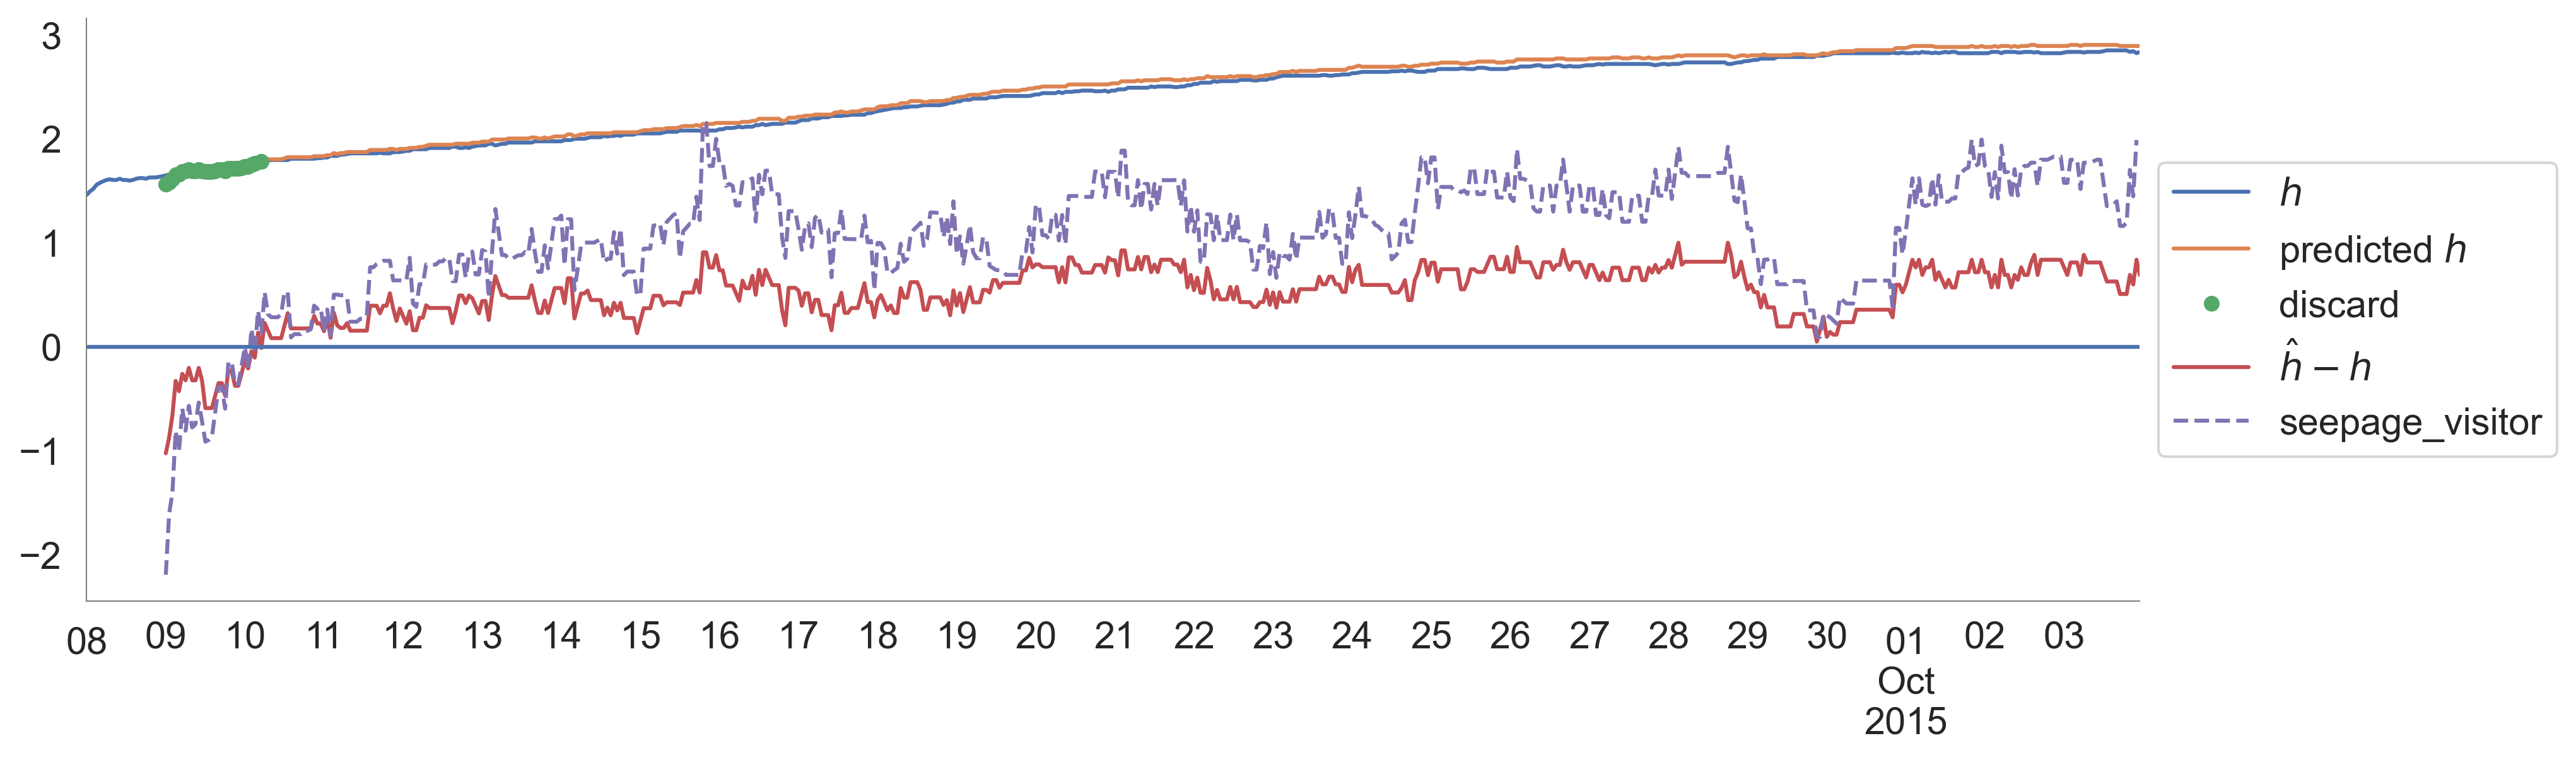

In [153]:
def plot_overwash_discard(merged, ind):

    subset = get_subset(merged, ind, 0, 0 )
    hourly_subset = get_hourly_visitor(subset).query("State_visit == 1")

    # keep indices where predicted h > observed h
    keep = hourly_subset[(hourly_subset[ 'visitor_h_Q']- hourly_subset['visitor_filled']) >  -0.0].index
    # discard indices where predicted h < observed h
    discard = hourly_subset[(hourly_subset[ 'visitor_h_Q']- hourly_subset['visitor_filled']) < -0.0].index

    fig, ax = plt.subplots(1, figsize = (14,4))
    rename = {"visitor_filled" : "$h$", "visitor_h_Q" : "predicted $h$"}
    hourly_subset[['visitor_filled', 'visitor_h_Q']].rename(rename, axis = 1).plot(ax =ax)

    if len(discard) > 0:
        hourly_subset.loc[discard][[ 'visitor_h_Q']].rename(
            {"visitor_h_Q": "discard"}, axis = 1).plot(marker = 'o', ms = 5, ls = '', ax = ax)

    (hourly_subset[['h_hat_minus_h']].apply(scale_series, maxval = 1)).rename(
        {"h_hat_minus_h": "$\hat h - h$"}, axis = 1).plot(ax =ax)

    (hourly_subset.iloc[:-1][[ 'seepage_visitor']]).plot(ax = ax, ls = '--')

    ax.axhline(0)

    ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))
    print (len(discard))

    
plot_overwash_discard(merged, 3)

In [154]:
subset = get_subset(merged, 12, 0, 0)

hourly_subset = get_hourly_visitor(subset).query("State_visit == 1")

daily_subset = get_daily_subset(subset, include_USGS = 0, periods = 1)
daily_subset.index.date[[0, -1]]

array([datetime.date(2013, 9, 26), datetime.date(2013, 10, 15)],
      dtype=object)

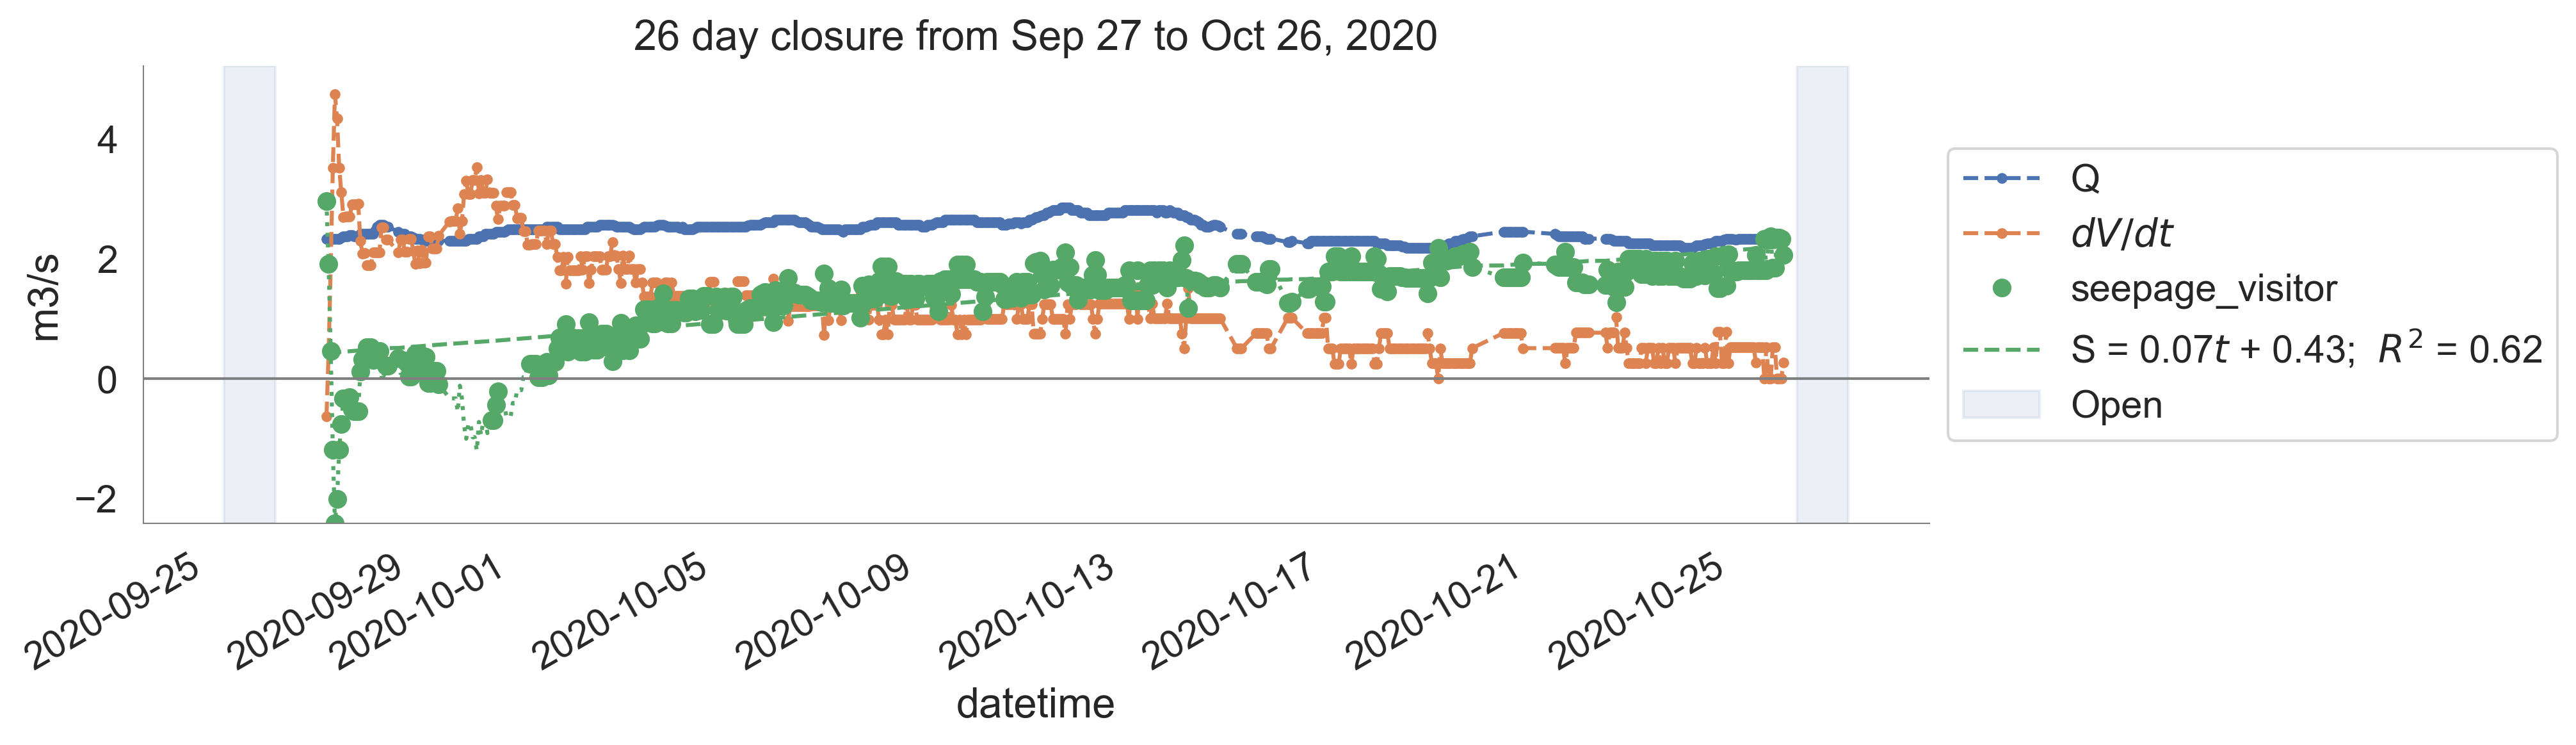

In [155]:
ind = 1

subset =  get_subset(merged, ind, 0, 0)

fig, ax = plt.subplots( 1, figsize = (12, 3.5))
plt.subplots_adjust(hspace = 0.35)
plot_mass_bal_hourly(merged_wave,  ind, padding  = 1, logscale = False, ax = ax);

## Mass balance plots

In [156]:
# plt.rcParams['figure.figsize'] = (12.0, 6.0)
# for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
#     if mod in sys.modules:
#         del sys.modules[mod]

# import plot_config
# from timeseries_functions import *
# from seepage_analysis import *
# from seepage_plots import *
# import matplotlib as mpl

# from matplotlib.ticker import MaxNLocator
# import matplotlib.dates as mdates
# from matplotlib.dates import DateFormatter


# mpl.rcParams['figure.dpi'] = 300

###  Diagnostic plots

In [157]:

# def filter_overtop(subset, minval = 0):

#     hourly_subset = get_hourly_visitor(subset)
#     if 'visitor_h_Q' in hourly_subset.columns:
#         lose = hourly_subset[(hourly_subset['visitor_h_Q']- hourly_subset['visitor_h']) < minval].index
#         lose = np.unique(lose.date)
#         return lose
#     else:
#         return
    # one_day = timedelta(days=1)
    # dates_plus_one = [date + one_day for date in lose]
    # lose = list(lose)+ dates_plus_one



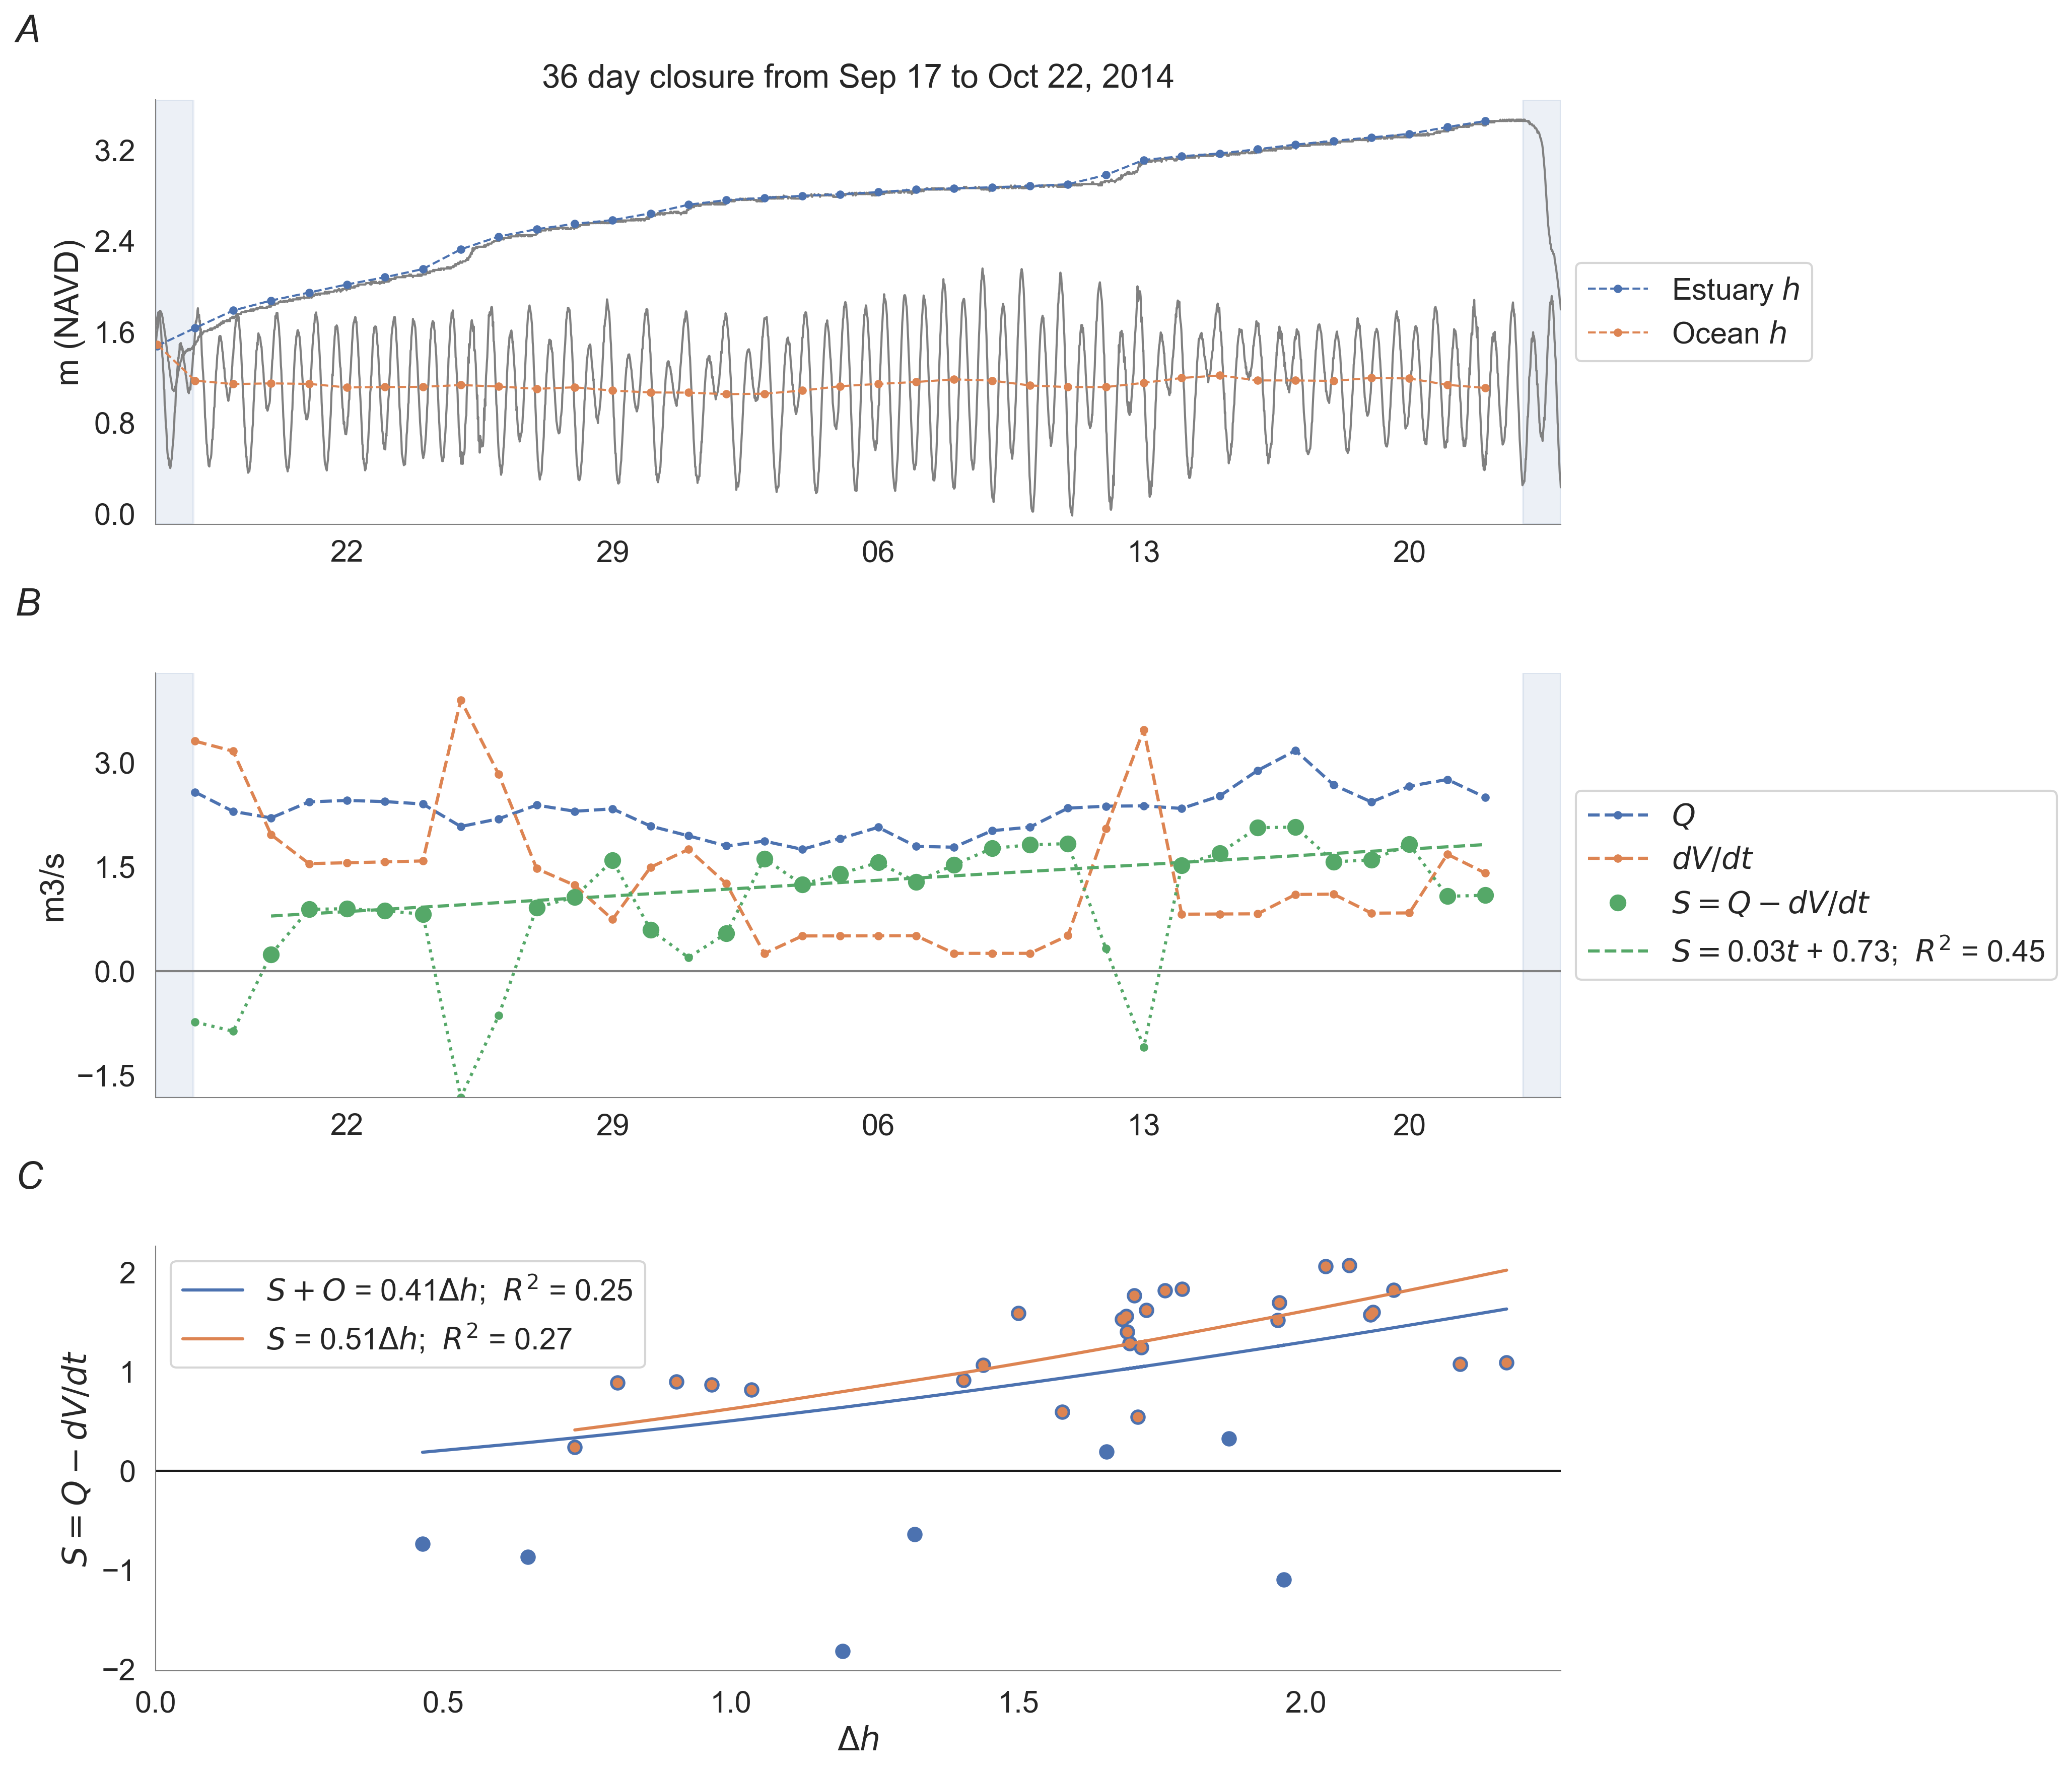

In [158]:

def hide_axes(ax):
    # Hide the spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Hide the ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])


def plot_mass_bal_visit(merged_case, ind, ax, padding = 10, logscale = 1,
                        legend_loc = 'outside',
                        regression_line = True):
    """

    """
    subset =  get_subset(merged_case, ind, padding, padding)

    closure_subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset).query("seepage_visitor < 8")
    daily_subset['date'] = daily_subset.index.date
    daily_subset['day'] = np.arange(len(daily_subset))


    # fixes x-axis limits
    subset[[ 'v']].rename({'v' : ''}, axis= 1).plot(ax = ax, visible = False)

    # Create a boolean mask where 'State_visit' > 0
    closed = daily_subset['State_visit'] > 0
    closed = daily_subset[closed].index

    daily_subset['Q'].plot(secondary_y=False, xlabel='Time', style='C0.--',
                        legend=True, ax = ax, label = '$Q$')

    (daily_subset['dvol/dt_visitor_filled']).plot(xlabel='Time', ylabel='m3/s',
                            style = 'C1.--', ax = ax, label = '$dV/dt$')

    (daily_subset['seepage_visitor']).plot(xlabel='Time', ylabel='m3/s',
                                    style = 'C2:.', ax = ax, label = '')

    #(daily_subset['waveHs']).plot(xlabel='Time', ylabel='m3/s',
    #                                style = 'C3:.', ax = ax, label = '')

    lose = filter_overtop(closure_subset, minval = 0.00)
    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset[['day', 'date', 'seepage_visitor']].dropna()
    pos_subset = pos_subset.query("seepage_visitor > 0")

    if len(pos_subset) > 0:

        (pos_subset['seepage_visitor']).plot(xlabel='Time', ylabel='m3/s',
                                        style = 'C2o', ms = 7, ax = ax, label = '$S = Q - dV/dt$')

    if len(pos_subset) > 0 and regression_line == True:

        X = pos_subset[['day']]
        y =  pos_subset['seepage_visitor']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y,
                                                                                    fit_intercept = True)
        pos_subset['predictions'] = predictions

        (pos_subset['predictions']).plot(style = 'C2--', ax = ax,
            label=f'$S = ${slope:.2f}$t$ + {intercept:.2f};  $R^2$ = {r_squared:.2f}')

    ax.axhline(0, c = 'grey', lw = 1)

    ymin, ymax = get_ylim_visitor(daily_subset.loc[closed])
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.set_ylabel("m3/s")

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "")

    if legend_loc == 'outside':
        ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend(title = '', loc=legend_loc)

    ax.set_xlabel('')
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    date_form = DateFormatter("%m-%d")
    ax.xaxis.set_major_formatter(date_form)

    return ax


def plot_12hr_visit(merged_case, ind, ax, legend_loc = 'outside', padding = 10, wind = False, wave = False):
    """
    """
    subset =  get_subset(merged_case, ind, padding, padding)

    closure_subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, periods = 1 )
    closed = daily_subset.index

    #subset[[ 'visitor_12_hr']].plot(ax = ax, linestyle = '--',  drawstyle='steps')

    if wave == True:

        subset[[ 'visitor_filled', 'v', 'waveHs']].rename(
            {'visitor_filled' : '', 'v' : '', 'waveHs' : '', 'wind' : ''}, axis= 1).plot(
            c = 'grey', alpha = 1,  ax = ax, linewidth= 1)

        daily_subset[['waveHs']].rename({'waveHs' : 'wave height'}, axis= 1).plot(
            c = 'green', alpha = 1,  ax = ax, linewidth= 1)

    elif wind == True:

        subset[['visitor_filled', 'v']].rename(
            {'visitor_filled' : '', 'v' : '',  'wind' : ''}, axis= 1).plot(
            c = 'grey', alpha = 1,  ax = ax, linewidth= 1)

        (daily_subset[['wind']]/10).rename({'wind' : 'wind'}, axis= 1).plot(
            c = 'green', alpha = 1,  ax = ax, linewidth= 1)

    else:

        subset[['visitor_filled', 'v']].rename(
            {'visitor_filled' : '', 'v' : '',  'wind' : ''}, axis= 1).plot(
            c = 'grey', alpha = 1,  ax = ax, linewidth= 1)


    daily_subset[['visitor_filled', 'v']].rename(
        {'visitor_filled' : 'Estuary $h$', 'v' : 'Ocean $h$',}, axis= 1
            ).plot(ax = ax,  marker = '.', linestyle = '--', linewidth= 1)

    ax.set_ylabel("m (NAVD)")
    ax.yaxis.set_major_locator(MaxNLocator(5))

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "")

    if legend_loc == 'outside':
        ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend(title = '', loc=legend_loc)

    ax.set_ylim(ax.get_ylim()[0]*0.5, ax.get_ylim()[1])

    ax.set_xlabel('')
    title = "{0} day closure from {1} to {2}".format(len(closed),
                closed[0].date().strftime("%b %d"),
                closed[-1].date().strftime("%b %d, %Y"))


    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    date_form = DateFormatter("%m-%d")
    ax.xaxis.set_major_formatter(date_form)

    return title, len(closed)


def plot_visitor_scatter(merged_case, ind, ax, offset = 0, power = 1):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1).query("seepage_visitor < 6")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h', 'waveHs']].dropna()
    daily_subset['date'] = daily_subset.index.date

    daily_subset = daily_subset
    ax.scatter(daily_subset['delta_h'], daily_subset['seepage'], label='', s = 40)
    # Linear regression model without intercept
    X = (daily_subset[['delta_h']]*(daily_subset[['delta_h']] + offset)**power).values.reshape(-1, 1)
    y =  daily_subset['seepage']

    if len(X) > 0:

        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.plot(daily_subset['delta_h'], predictions, color='C0',
            label=f'$S+O$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    lose = filter_overtop(subset, minval = 0.0)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset.query("seepage > 0")
    if len(pos_subset) > 0:

        #X = pos_subset[['delta_h']]**power
        X = (pos_subset[['delta_h']]*(pos_subset[['delta_h']] + offset)**power).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'], label='', s = 15)

        ax.plot(pos_subset['delta_h'], predictions, color='C1',
            label=f'$S$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    ax.set_ylabel('$S = Q - dV/dt$')
    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left')
    ax.set_xlim(0, )
    ax.axhline(0, c = 'k', lw = 1)

# def plot_visitor_scatter_offset(merged_case, ind, ax, offset = 0.3):
#     """
#     """
#     subset =  get_subset(merged_case, ind, 0, 0)

#     daily_subset = get_daily_subset(subset, periods = 1).query("seepage_visitor < 6")

#     daily_subset['seepage'] =  daily_subset['seepage_visitor']
#     daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

#     # Calculate Δh
#     daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
#     daily_subset = daily_subset[['seepage', 'delta_h', 'waveHs']].dropna()
#     daily_subset['date'] = daily_subset.index.date

#     daily_subset = daily_subset
#     ax.scatter(daily_subset['delta_h'], daily_subset['seepage'], label='', s = 40)
#     # Linear regression model without intercept
#     X = daily_subset[['delta_h']]*(daily_subset[['delta_h']] + 0.3).values.reshape(-1, 1)
#     y =  daily_subset['seepage']

#     if len(X) > 0:

#         predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

#         ax.plot(daily_subset['delta_h'], predictions, color='C0',
#             label=f'$S+O$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

#     lose = filter_overtop(subset, minval = 0.0)

#     pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
#     pos_subset = pos_subset.query("seepage > 0")
#     if len(pos_subset) > 0:

#         X = pos_subset[['delta_h']]*(pos_subset[['delta_h']] + offset).values.reshape(-1, 1)**b
#         y = pos_subset['seepage']
#         predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

#         ax.scatter(pos_subset['delta_h'], pos_subset['seepage'], label='', s = 15)

#         ax.plot(pos_subset['delta_h'], predictions, color='C1',
#             label=f'$S$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

#     ax.set_ylabel('$S = Q - dV/dt$')
#     ax.set_xlabel('$\Delta h$')
#     ax.legend(loc = 'upper left')
#     ax.set_xlim(0, )
#     ax.axhline(0, c = 'k', lw = 1)
 
    
ind = 0

merged_case = merged_wave

for ind in range(1):

    subset =  get_subset(merged_case, ind, 0, 0)

    fig, axes = plt.subplots(3, 1, figsize = (12, 13.5))
    plt.subplots_adjust(hspace = 0.35)

    title, duration = plot_12hr_visit(merged_case, ind, axes[0], wind = False, padding  = 1)

    plot_mass_bal_visit(merged_case, ind, padding  = 1, logscale = False,
                        regression_line = True, ax = axes[1])

    plot_visitor_scatter(merged_case, ind, axes[2], offset = 0.5, power = 0.5)


    axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[0].set_title(title)
    axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[0].set_xticks([])
    date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)

    plt.savefig(
        root + 'figures/visitor_closures/{1}days__{0}.png'.format(subset.iloc[0].name.date(), duration),
        bbox_inches='tight'
    )

    

In [159]:
# -----------------------------------------------------------------------------
# Build a pooled, event-labeled panel of daily records
# - Stacks all days from all events into one DataFrame (no aggregation).
# - Applies standard filters:
#       * keep days with seepage_visitor < 5 (screen out suspect values)
#       * drop rows with NaNs in key fields
#       * remove dates flagged as overtopping (via filter_overtop)
#       * keep only positive seepage
# - Computes Δh = visitor_filled - v
# - Labels each row with its event index for later fixed/random-effects modeling
#   (e.g., OLS with C(event) or mixed models with random intercepts).
# -----------------------------------------------------------------------------

pooled_event_df = pd.DataFrame()

for ind in range(30):
    subset =  get_subset(merged_case, ind, 0, 0)
    
    # Daily rollup + initial screen
    daily_subset = (get_daily_subset(subset, periods = 1)
        .query("seepage_visitor < 5")
        .copy())

    # Prepare fields
    daily_subset["seepage"] = daily_subset["seepage_visitor"]
    daily_subset["State_visit"] = np.floor(daily_subset["State_visit"])
    
    # Calculate Δh
    daily_subset["delta_h"] = daily_subset["visitor_filled"] - daily_subset["v"]
    daily_subset = daily_subset[["seepage", "delta_h", "waveHs", "visitor_h"]].dropna()
    daily_subset["date"] = daily_subset.index.date


    # Remove overtopping dates
    lose = filter_overtop(subset, minval=0.0)
    pos_subset = daily_subset[~daily_subset["date"].isin(lose)]
    pos_subset = pos_subset.query("seepage > 0").copy()
 
    pos_subset["event"] = ind

    if len(pos_subset) > 0:
        pooled_event_df = pd.concat([pooled_event_df, pos_subset], axis=0)
    

In [160]:
pooled_event_df.to_csv(data_path + "processed/pooled_event_df.csv")

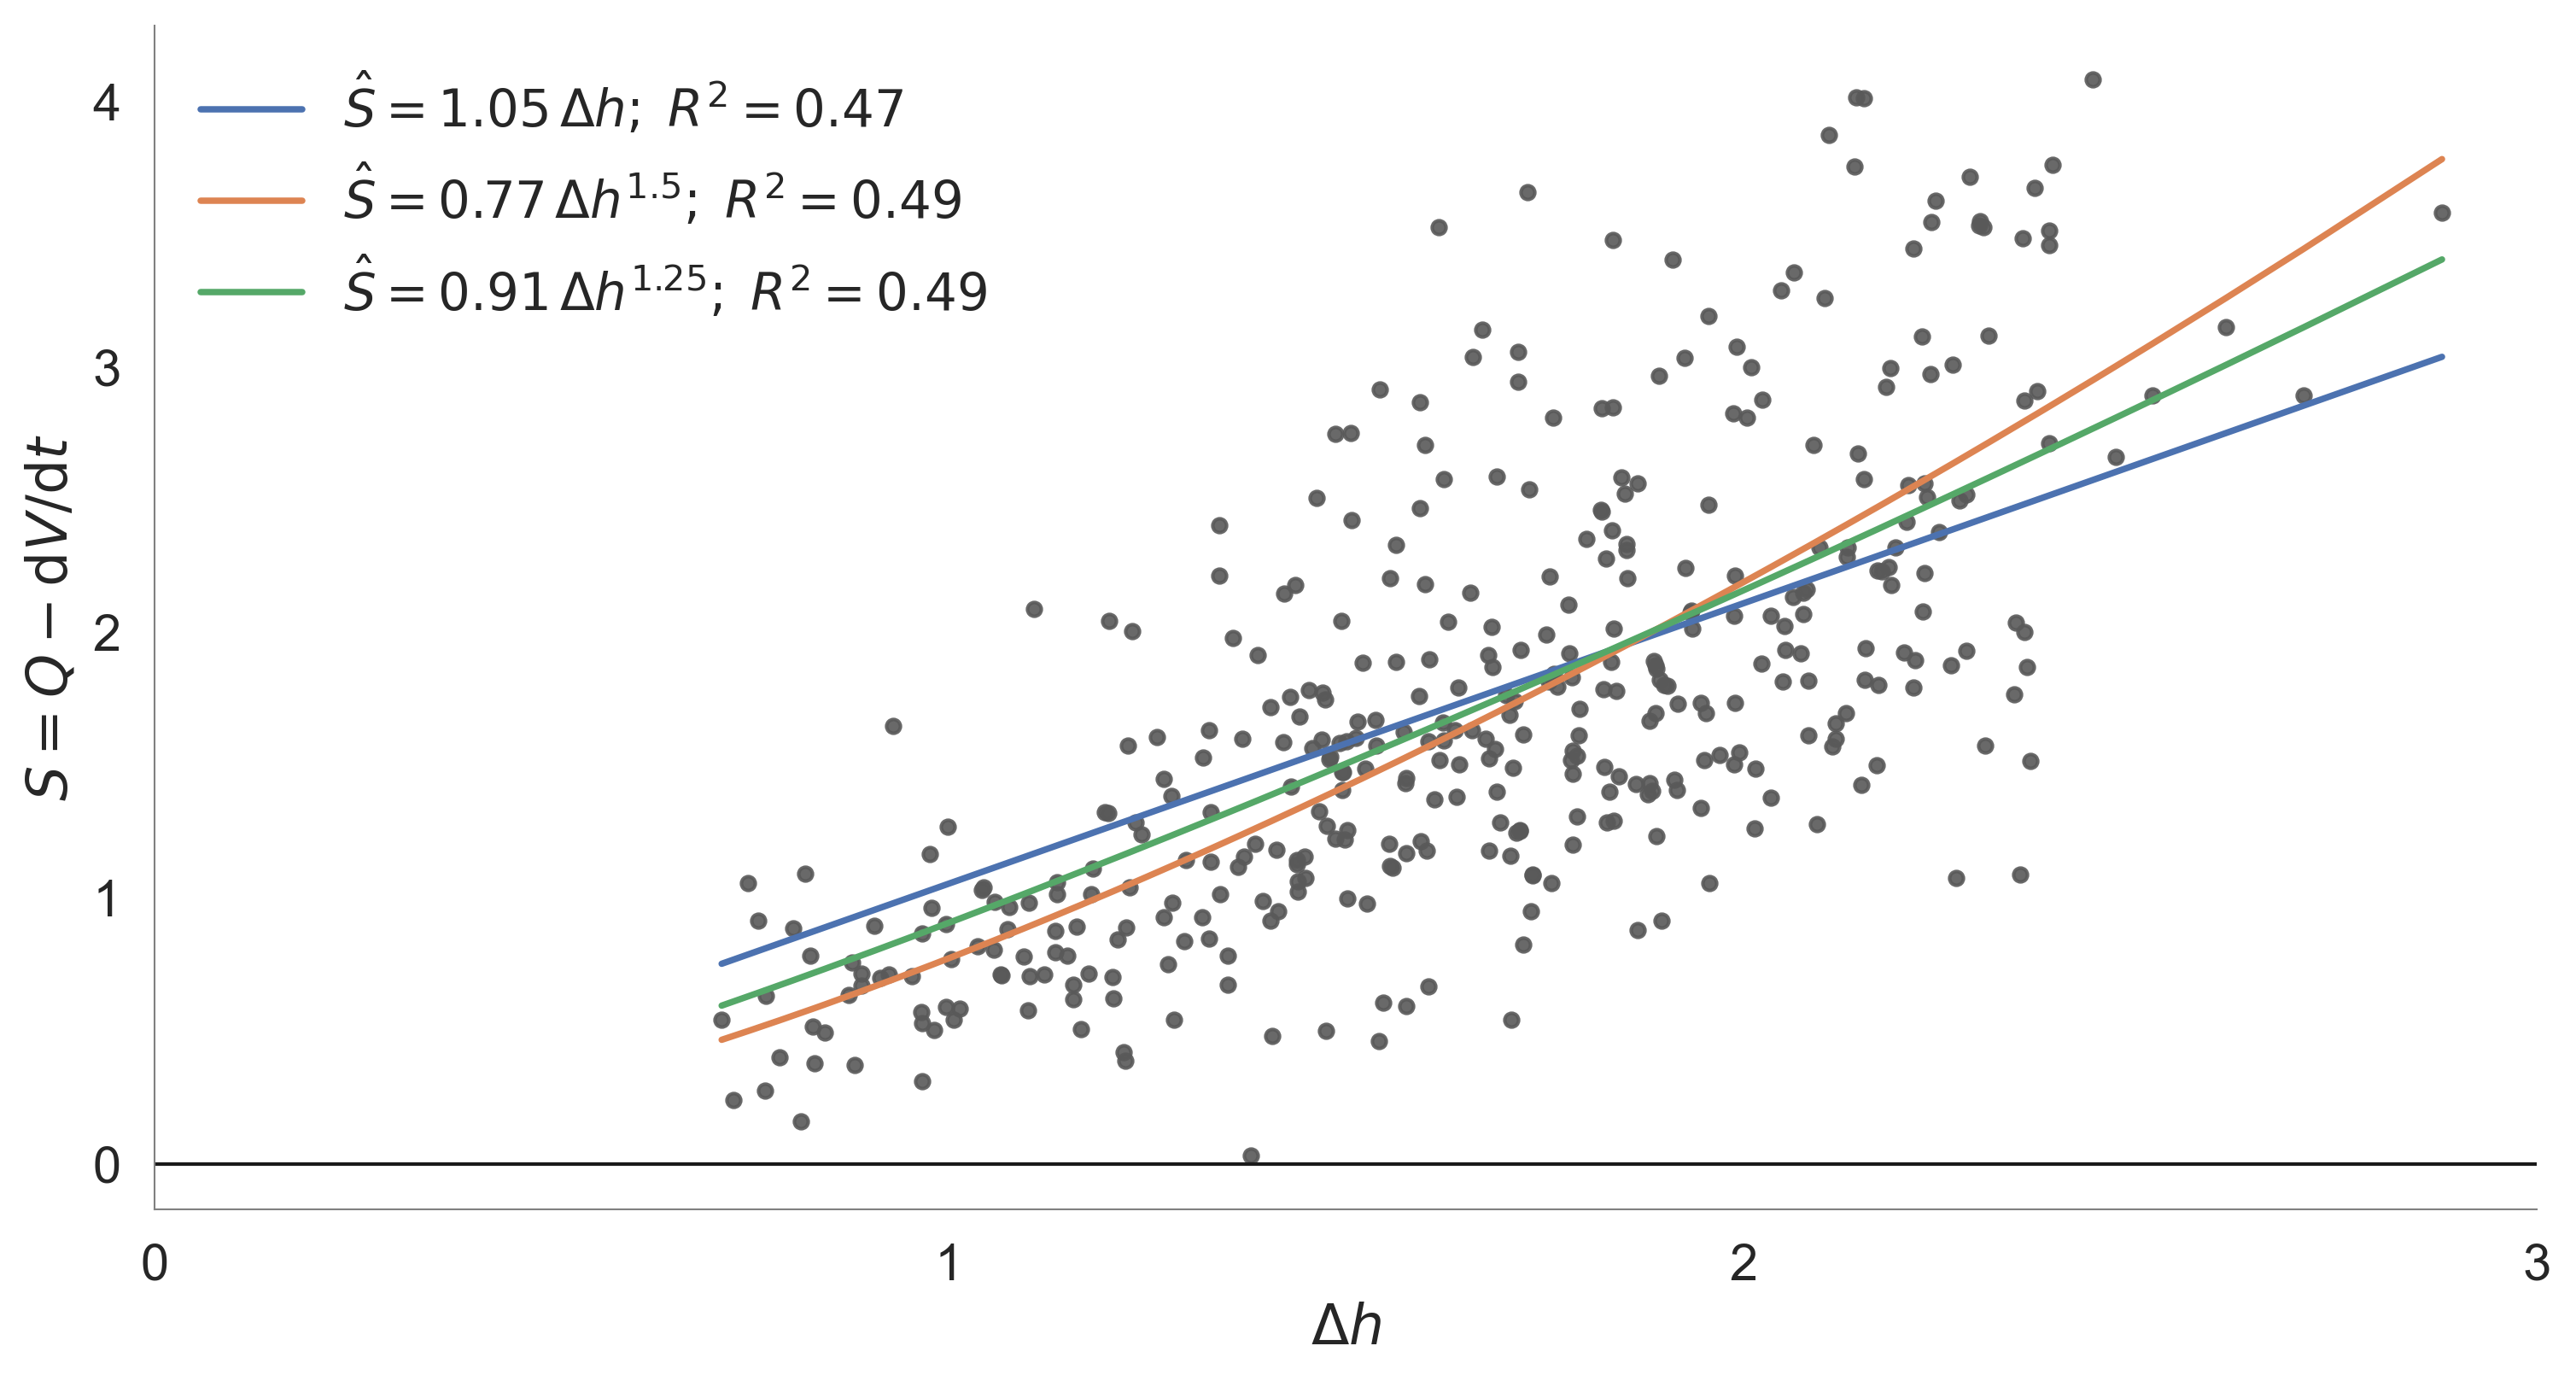

In [161]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

def _exp_str(p: float) -> str:
    """Return mathtext exponent: 1 -> '', int -> '^{n}', else '^{1.25}'."""
    if np.isclose(p, 1.0):
        return ""
    if np.isclose(p, round(p)):
        return f"^{{{int(round(p))}}}"
    return f"^{{{p:.3g}}}"   # braces ensure full decimal is superscripted

def plot_seepage_vs_delta_h(
    grouped: pd.DataFrame,
    fit_fn,                          # your fit_Xy(X, y) -> preds, slope, intercept, r2, t, ci_lo, ci_hi, resid
    powers=(1.0, 1.5, 1.25),
    ax=None,
    scatter_kwargs=None,
    line_kwargs=None,
    xticks=(0, 1, 2, 3),
    yticks=(0, 1, 2, 3, 4)):
    """
    Plot S vs Δh with multiple power-law fits using fit_fn(X, y).
    Expects columns 'delta_h' and 'seepage' in `grouped`.
    """
    # case-insensitive column handling
    colmap = {c.lower(): c for c in grouped.columns}
    if "delta_h" not in colmap or "seepage" not in colmap:
        raise ValueError("grouped must have columns 'delta_h' and 'seepage'")

    df = grouped[[colmap["delta_h"], colmap["seepage"]]].astype(float).dropna()
    df = df.sort_values(colmap["delta_h"]).rename(columns={colmap["delta_h"]: "delta_h",
                                                           colmap["seepage"]: "seepage"})

    if ax is None:
        ax = plt.gca()

    # styles
    scatter_kwargs = {"s": 15, "c": "0.35", "alpha": 0.9} | (scatter_kwargs or {})
    line_kwargs    = {"lw": 1.8} | (line_kwargs or {})
    palette = ["C0", "C1", "C2", "C3", "C4"]

    # scatter
    ax.scatter(df["delta_h"], df["seepage"], **scatter_kwargs)

    fits = {}
    for i, p in enumerate(powers):
        X = (df[["delta_h"]] ** p).astype(float)
        y = df["seepage"].to_numpy()
        preds, slope, intercept, r2, tval, ci_lo, ci_hi, residuals = fit_fn(X, y)

        exp_part = _exp_str(p)
        label = rf"$\hat{{S}}={slope:.2f}\,\Delta h{exp_part};\; R^2={r2:.2f}$"
        ax.plot(df["delta_h"], preds, color=palette[i % len(palette)], label=label, **line_kwargs)

        fits[p] = {"slope": slope, "intercept": intercept, "r2": r2,
                   "t": tval, "ci": (ci_lo, ci_hi), "residuals": residuals}

    # axes labels (mathtext)
    ax.set_xlabel(r"$\Delta h$")
    ax.set_ylabel(r"$S = Q - \mathrm{d}V/\mathrm{d}t$")

    # limits/ticks
    xmax = float(np.nanmax(df["delta_h"])) if len(df) else 1.0
    ax.set_xlim(0, np.ceil(xmax))
    if xticks is not None: ax.set_xticks(xticks)
    if yticks is not None: ax.set_yticks(yticks)

    # baseline & legend
    ax.axhline(0, color="k", lw=1)
    ax.legend(loc="upper left", frameon=False)

    return ax, fits

ax, fits = plot_seepage_vs_delta_h(grouped, fit_Xy)  # default fits: Δh, Δh^1.5, Δh^1.25
plt.show()


In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

ind = 0

subset =  get_subset(merged_case, ind, 0, 0)
fig, axes = plt.subplots(2, 2, figsize = (17, 9.5))
axes = axes.ravel()
plt.subplots_adjust(hspace = 0.3)
plt.subplots_adjust(wspace = 0.2)

title = plot_12hr_visit(merged_case, ind, axes[0], legend_loc = 'upper left', padding  = 2)
plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, legend_loc = 'upper right',
                    regression_line = False, ax = axes[1])
plot_visitor_scatter(merged_case, ind, axes[2], power =1)

axes[1].set_ylim(axes[1].get_ylim()[0], axes[1].get_ylim()[1]*1.4)

axes[0].text(-0.1, 1.15, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[0].text(0.1, 1.15, title, transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'normal');

axes[1].text(-0.1, 1.15, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.15, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[3].text(-0.1, 1.15, 'D', transform=axes[3].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
hide_axes(axes[3])
date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)


In [ ]:
closure_subset =  get_subset(merged_case, 0, 0, 0)

daily_subset = get_daily_subset(closure_subset, periods = 1 )
closed = daily_subset.index

In [ ]:
daily_subset.iloc[[14, 24]]['visitor_h'].diff()

In [ ]:
# daily_subset.visitor_h - daily_subset.v

In [ ]:


def plot_visitor_power(merged_case, ind, ax, power = [1,1.25, 1.5]):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1)
    #print (daily_subset.index[0].date(), "duration = {0} days" .format( len(daily_subset)))
    daily_subset = daily_subset.query("seepage_visitor < 6")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h', 'waveHs', 'visitor_h']].dropna()
    daily_subset['date'] = daily_subset.index.date

    # daily_subset = daily_subset
    lose = filter_overtop(subset, minval=0.0)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset.query("seepage > 0 ")
    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]**power[0]
        # X = (pos_subset['delta_h'] * pos_subset['visitor_h']**power[0]).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residual = fit_Xy(X, y)
        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'],  c= 'grey', label='', s = 15)
        ax.plot(pos_subset['delta_h'], predictions, color='C0', ls = '--',
            label=f'$b$ = {power[0]:.0f};  $R^2$ = {r_squared:.2f}')

        X = pos_subset[['delta_h']]**power[1]
        # X = (pos_subset['delta_h'] * pos_subset['visitor_h']**power[1]).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residual = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C1', ls = '--',
            label=f'$b$ = {power[1]:.2f};  $R^2$ = {r_squared:.2f}')


        X = pos_subset[['delta_h']]**power[2]
        # X = (pos_subset['delta_h'] * pos_subset['visitor_h']**power[2]).values.reshape(-1, 1)
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residual = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C2', ls = '--',
            label=f'$b$ = {power[2]:.1f};  $R^2$ = {r_squared:.2f}')

    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left', handlelength = 1, fontsize = 14)
    #ax.set_xlim(0, )
    ax.axhline(0, c = 'k', lw = 1)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())


fig, axes = plt.subplots(1,3, figsize = (14, 4), sharex = True, sharey = True)

plot_visitor_power(merged_case, 0, axes[0])
axes[0].set_ylabel('$S = Q - dV/dt$')
plot_visitor_power(merged_case, 1, axes[1])
plot_visitor_power(merged_case, 2, axes[2])
axes[0].set_xticks([1,2,3]);
axes[0].set_yticks([1,2,3]);
axes[0].set_xlim(0.5, 3)
axes[0].set_ylim(0, 4)

axes[0].text(-0.15, 1.05, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[1].text(-0.15, 1.05, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[2].text(-0.15, 1.05, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');


In [ ]:
def plot_visitor_power_exp(merged_case, ind, ax, power = [1,1.25,1.5]):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1)
    print (daily_subset.index[0].date(), "duration = {0} days" .format( len(daily_subset)))
    daily_subset = daily_subset.query("seepage_visitor < 6")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h', 'waveHs']].dropna()
    daily_subset['date'] = daily_subset.index.date

    # daily_subset = daily_subset
    lose = filter_overtop(subset, minval=0.0)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]
    pos_subset = pos_subset.query("seepage > 0 ")
    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]**power[0]
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'],  c= 'grey', label='', alpha = 0.6, s = 15)
        
        ax.plot(pos_subset['delta_h'], predictions, color='C0', ls = '--',
            label=f'$S$ = {slope:.2f}' + '$\Delta h^{1}$'+ f';  $R^2$ = {r_squared:.2f}')

        y =  pos_subset['seepage']
        X = pos_subset[['delta_h']]**power[1]        
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C1', ls = '--',
            label=f'$S$ = {slope:.2f}' + '$\Delta h^{1.25}$'+ f';  $R^2$ = {r_squared:.2f}')

        y =  pos_subset['seepage']
        X = pos_subset[['delta_h']]**power[2]        
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
        ax.plot(pos_subset['delta_h'], predictions, color='C2', ls = '--',
                        label=f'$S$ = {slope:.2f}' + '$\Delta h^{1.5}$'+ f';  $R^2$ = {r_squared:.2f}')


    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left', handlelength = 1, fontsize = 14)
    #ax.set_xlim(0, )
    ax.axhline(0, c = 'k', lw = 1)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

fig, axes = plt.subplots(2,2, figsize = (12, 9), sharex = True, sharey = True)
axes = axes.ravel()

plot_visitor_power_exp(merged_case, 0, axes[0])
plot_visitor_power_exp(merged_case, 1, axes[1])
plot_visitor_power_exp(merged_case, 2, axes[2])
axes[0].set_xticks([1,2,3]);
axes[0].set_yticks([1,2,3,]);
axes[0].set_xlim(0.5, 3)
axes[0].set_ylim(0, 4)
axes[0].set_ylabel('$S = Q - dV/dt$')

axes[0].text(-0.1, 1.05, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[1].text(-0.1, 1.05, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[2].text(-0.1, 1.05, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');
axes[3].text(-0.1, 1.05, 'D', transform=axes[3].transAxes, ha="left", va="top",
        fontsize = 16, style = 'italic');

ax = axes[3]

grouped = grouped.sort_values("delta_h")
ax.scatter(grouped['delta_h'], grouped['seepage'], label='', c= 'grey', alpha  = 0.5, s = 15)
X = grouped[['delta_h']]
y =  grouped['seepage']
predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)


ax.plot(grouped['delta_h'], predictions, "--",
    label=f'$S$ = {slope:.2f}' + '$\Delta h^{1}$'+ f';  $R^2$ = {r_squared:.2f}')
X = grouped[['delta_h']]**1.25
y =  grouped['seepage']
predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)


ax.plot(grouped['delta_h'], predictions, "--",
    label=f'$S$ = {slope:.2f}' + '$\Delta h^{1.25}$'+ f';  $R^2$ = {r_squared:.2f}')

X = grouped[['delta_h']]**1.5
y =  grouped['seepage']
predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
ax.plot(grouped['delta_h'], predictions,  "--",
    label=f'$S$ = {slope:.2f}' + '$\Delta h^{1.5}$'+ f';  $R^2$ = {r_squared:.2f}')

axes[2].set_ylabel('$S = Q - dV/dt$')
ax.set_xlabel('$\Delta h$')
ax.legend(loc = 'upper left')
ax.set_xlim(0.2, )
ax.set_ylim(0., 5)
ax.axhline(0, c = 'k', lw = 1)
ax.set_yticks([1, 2, 3, 4]);
ax.set_xticks([ 1, 2, 3]);

In [ ]:
# plt.rcParams['figure.figsize'] = (12.0, 6.0)
# for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
#     if mod in sys.modules:
#         del sys.modules[mod]

# import plot_config
# from timeseries_functions import *
# from seepage_analysis import *
# from seepage_plots import *
# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 300

## Code to summarize

In [ ]:

summary = pd.DataFrame()
for ind in range(40):
    best= optimize_exponent(merged_case, ind)
    summary = pd.concat([summary, best], axis = 1)

summary = summary.T.reset_index().drop('index', axis = 1).head(30)



In [ ]:
plt.figure(figsize = (10, 4))
plt.scatter(summary['best_R2'].astype(float), summary['R2'].astype(float))
plt.scatter(summary['best_R2'].iloc[:23].astype(float), summary['R2'].iloc[:23].astype(float))
plt.plot(summary['best_R2'].astype(float), summary['best_R2'].astype(float))

In [ ]:
summary['best_R2'].astype(float).median(), summary['R2'].astype(float).median()


In [ ]:
summary['best_R2'].iloc[:23].astype(float).median(), summary['R2'].iloc[:23].astype(float).median()

In [ ]:
summary['best_R2'].astype(float).mean(), summary['R2'].astype(float).mean()

In [ ]:
summary['b_best'].astype(float).mean(), summary['b_best'].iloc[:20].astype(float).mean()

In [ ]:
summary['b_best'].astype(float).median(), summary['b_best'].iloc[:20].astype(float).median()

In [ ]:
# summary[['date', 'duration', 'N', 'K_tilde_fmt', 'R2', 'b_best', 'best_R2']].sort_values('duration')

In [ ]:
print (summary[['date', 'duration', 'N', 'K_tilde_fmt', 'R2', 'b_best', 'best_R2']].to_latex(index= False
            ).replace("midrule", "hline")
            .replace("toprule", "hline")
            .replace("bottomrule", "hline").replace("K_tilde_fmt", "$\\tilde K$")
             .replace("b_best", "$b_{optim}$")
            .replace("best_R2", "$R^2_{optim}$")
            .replace("R2", "$R^2$")
            .replace('{lllllll}', '{lllll|ll}')
      )

In [ ]:
plt.figure(figsize = (6,3))
plt.scatter(summary.Q, summary.K_tilde)
# plt.scatter(summary.Q, summary.b_best.astype(float))
plt.xlabel("$Q$ (m3/s)")
plt.ylabel("$\\tilde K$ (m/s)")
ax = plt.gca()
ax.text(1.5, .95, " ", transform=ax.transAxes, ha="left", va="top")


###  Figures plots

In [ ]:

merged_case = merged_wave
for ind in range(30):

    subset =  get_subset(merged_case, ind, 0, 0)

    fig, axes = plt.subplots(3, 1,  figsize = (12, 13.5))
    plt.subplots_adjust(hspace = 0.35)
    plot_12hr_visit(merged_case, ind, axes[0], padding  = 2)
    plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, ax = axes[1])
    plot_visitor_scatter(merged_case, ind, axes[2])

    axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[0].set_xticks([])
    date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)
#     plt.savefig('visitor_closures/{1:.0f}days__{0}.png'.format(date,
#                                              len(subset.query("State_visit == 1"))/24/4), bbox_inches='tight')

In [ ]:
merged_case = merged_wave

ind = 36
subset =  get_subset(merged_case, ind, 0, 0)

fig, axes = plt.subplots(3, 1,  figsize = (12, 13.5))
plt.subplots_adjust(hspace = 0.35)
plot_12hr_visit(merged_case, ind, axes[0], padding  = 2)
plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, ax = axes[1])
plot_visitor_scatter(merged_case, ind, axes[2])

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_xticks([])
date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)
# plt.savefig('visitor_closures/{1:.0f}days__{0}.png'.format(date,
#                                          len(subset.query("State_visit == 1"))/24/4), bbox_inches='tight')

In [ ]:
ind = 37
subset =  get_subset(merged_case, ind, 0, 0)

fig, axes = plt.subplots(2, 1, sharex = True, figsize = (12, 7.5))
plt.subplots_adjust(hspace = 0.35)
plot_12hr_visit(merged_case, ind, axes[0], padding  = 2)
plot_mass_bal_visit(merged_case, ind, padding  = 2, logscale = False, ax = axes[1])


axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');


# Summarize

In [ ]:
plt.rcParams['figure.figsize'] = (12.0, 6.0)
for mod in ['plot_config', 'timeseries_functions', 'seepage_analysis', 'seepage_plots']:
    if mod in sys.modules:
        del sys.modules[mod]

import plot_config
from timeseries_functions import *
from seepage_analysis import *
from seepage_plots import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [ ]:
import numpy as np

def bootstrap_median_ci(data, n_bootstrap=1000, ci=95):
    """
    Calculate the confidence interval for the median of a dataset using the bootstrap method.

    :param data: List or numpy array of data points
    :param n_bootstrap: Number of bootstrap samples to generate
    :param ci: Confidence level (between 0 and 100)
    :return: Tuple containing lower and upper bounds of the confidence interval
    """
    medians = np.array([np.median(np.random.choice(data, size=len(data)-1, replace=True)) for _ in range(n_bootstrap)])
    lower_bound = np.percentile(medians, (100 - ci) / 2)
    upper_bound = np.percentile(medians, 100 - (100 - ci) / 2)

    return lower_bound, upper_bound


def get_row(merged_case, ind, offset = 0, exponent = 1, filters = None):
    """
    """
    subset =  get_subset(merged_case, ind, 0, 0)

    daily_subset = get_daily_subset(subset.query("State_visit == 1"))
    daily_subset['day'] = np.arange(len(daily_subset))

    duration = len(daily_subset)

    daily_subset = daily_subset.query("seepage_visitor < 4")

    daily_subset['seepage'] =  daily_subset['seepage_visitor']
    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.visitor_filled - daily_subset.v
    daily_subset['date'] = daily_subset.index.date

    #daily_subset = daily_subset[:-1]

    if filters == 'forecast':

        # Only include values for which overwash estimates are zero
        hourly_subset = get_hourly_visitor(subset)

        lose = filter_overtop(subset, minval=0.0)
        if len(lose) > 0:
            daily_subset = daily_subset[~(daily_subset.index).isin(lose)]
        daily_subset = daily_subset.query("seepage > 0")

    elif filters == 'positive':
        
        daily_subset = daily_subset.query("seepage > 0")

    daily_subset = daily_subset[['seepage', 'delta_h', 'Q', 'day', 'visitor_h']].dropna().query('seepage < 4')

    # Linear regression model without intercept
    #X = (daily_subset['delta_h']**offset * daily_subset['visitor_h']**0).values.reshape(-1, 1)


    X = (daily_subset['delta_h'] * (daily_subset['delta_h'] + offset)**exponent).values.reshape(-1, 1)

    y =  daily_subset['seepage']

    if len(X) > 3:
        Ks_predictions, Ks, intercept, Ks_r2, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
    else:
        return

    SQ = daily_subset[['seepage', 'Q']].dropna()
    SQ_ratio =  SQ['seepage']/SQ['Q']
    S_CI = bootstrap_median_ci(daily_subset['seepage'])
    SQ_CI = bootstrap_median_ci(SQ_ratio)

    X = daily_subset[['day']]
    y = daily_subset['seepage']

    S_predictions, dSdt, S_intercept, S_R2, t_value, dSdt_CI_low, dSdt_CI_high, residuals = \
            fit_Xy(X, y, fit_intercept = True)


    row = pd.Series(
            {
            'ind' : ind,
            'duration'  : duration,
            'offset' : offset,
            'exponent' : exponent,                
            'N': len(daily_subset),
            'date': daily_subset.iloc[0].name.date(),
            'year': daily_subset.iloc[0].name.year,
            'month': daily_subset.iloc[0].name.month,
            # regression fits on Ks
            'Ks' : np.round(float(Ks),3),
            'CI_low' : CI_low,
            'CI_high' : CI_high,
            'R2' : np.round(Ks_r2,3),
            # seepage estimates
            'S' : np.round(daily_subset['seepage'].median(), 3),
            'S_max' : np.round(daily_subset['seepage'].max(), 3),
            'S_min' : np.round(daily_subset['seepage'].min(), 3),
            'S_CI_low' : S_CI[0],
            'S_CI_high' : S_CI[1],
            # seepage trends
            'dSdt' : dSdt,
            'dSdt_CI_low' : dSdt_CI_low,
            'dSdt_CI_high' : dSdt_CI_high,
            # discharge
            'delta_h' : np.round(daily_subset['delta_h'].mean(), 3),
            'delta_h_min' : np.round(daily_subset['delta_h'].min(), 3),
            'delta_h_max' : np.round(daily_subset['delta_h'].max(), 3),
            # discharge
            'Q' : np.round(daily_subset['Q'].mean(), 3),
            'Q_min' : np.round(daily_subset['Q'].min(), 3),
            'Q_max' : np.round(daily_subset['Q'].max(), 3),

            # seepage fraction
            'SQ' : np.round(SQ['seepage'].sum()/SQ['Q'].sum(), 3),
            'SQ_min' : np.round(SQ_ratio.min(), 3),
            'SQ_max' : np.round(SQ_ratio.max(), 3),
            'SQ_CI_low' : SQ_CI[0],
            'SQ_CI_high' : SQ_CI[1],
            #
            'delta_h' : np.round(daily_subset['delta_h'].median(), 3),
            'S_list' :
                list(daily_subset['seepage']),
            'Q_list' : list(daily_subset['Q']),
            }, name = ind)

    return row

def compile_summary(merged_case, num, offset = 0, exponent = 1, filters = None):

    summary = pd.DataFrame()

    for ind in range(num):

        row = get_row(merged_case, ind, offset = offset, exponent = exponent, filters = filters)
        summary = pd.concat([summary, row], axis = 1)

    return summary.T


def get_row_USGS(ind, filters = None,offset = 0 ):
    """
    """
    subset =  get_subset_USGS(merged, ind, 0, 0,)

    daily_subset = get_daily_subset_USGS(subset.query("State_USGS == 1"))
    daily_subset['day'] = np.arange(len(daily_subset))

    duration = len(daily_subset)
    daily_subset['seepage'] = (daily_subset['Q'] - daily_subset['dvol/dt_USGS_filled']
                                     ).where(daily_subset['State_USGS'] == 1)

    daily_subset['State_USGS'] = daily_subset['State_USGS'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.USGS_filled - daily_subset.v


    if filters == 'forecast':
        # Only include values for which overwash estimates are zero
        hourly_subset = get_hourly_USGS(subset)

        if 'USGS_h_Q' in hourly_subset.columns:

            lose = hourly_subset[(hourly_subset[ 'USGS_h_Q'] - hourly_subset['USGS_h']) < -0.02].index
            lose = np.unique(lose.date)
            lose = list(lose)
            daily_subset = daily_subset[~(daily_subset.index).isin(lose)]
        else:
            return


    elif filters == 'positive':

        daily_subset = daily_subset.query("seepage > 0")


    daily_subset = daily_subset[['seepage', 'delta_h', 'Q', 'day', 'USGS_h']].dropna().query('seepage < 4')

    # Linear regression model without intercept

    X = (daily_subset['delta_h']**offset).values.reshape(-1, 1)
    y =  daily_subset['seepage']

    if len(X) > 3:
        Ks_predictions, Ks, intercept, Ks_r2, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)
    else:
        return

    SQ = daily_subset[['seepage', 'Q']].dropna()
    SQ_ratio =  SQ['seepage']/SQ['Q']
    S_CI = bootstrap_median_ci(daily_subset['seepage'])
    SQ_CI = bootstrap_median_ci(SQ_ratio)


    X = daily_subset[['day']]
    y = daily_subset['seepage']

    S_predictions, dSdt, S_intercept, S_R2, t_value, dSdt_CI_low, dSdt_CI_high, residuals = \
                fit_Xy(X, y, fit_intercept = True)


    row = pd.Series(
            {
            'duration'  : duration,
            'offset' : offset,
            'exponent' : exponent,
            'N': len(daily_subset),
            'date': daily_subset.iloc[0].name.date(),
            'year': daily_subset.iloc[0].name.year,
            'month': daily_subset.iloc[0].name.month,
            # regression fits on Ks
            'Ks' : np.round(float(Ks),3),
            'CI_low' : CI_low,
            'CI_high' : CI_high,
            'R2' : np.round(Ks_r2,3),
            # seepage estimates
            'S' : np.round(daily_subset['seepage'].median(), 3),
            'S_max' : np.round(daily_subset['seepage'].max(), 3),
            'S_min' : np.round(daily_subset['seepage'].min(), 3),
            'S_CI_low' : S_CI[0],
            'S_CI_high' : S_CI[1],
            # seepage trends
            'dSdt' : dSdt,
            'dSdt_CI_low' : dSdt_CI_low,
            'dSdt_CI_high' : dSdt_CI_high,
            # discharge
            'Q' : np.round(daily_subset['Q'].median(), 3),
            # seepage fraction
            'SQ' : np.round(SQ['seepage'].sum()/SQ['Q'].sum(), 3),
            'SQ_min' : np.round(SQ_ratio.min(), 3),
            'SQ_max' : np.round(SQ_ratio.max(), 3),
            'SQ_CI_low' : SQ_CI[0],
            'SQ_CI_high' : SQ_CI[1],
            #
            'delta_h' : np.round(daily_subset['delta_h'].median(), 3),
            'S_list' : list(daily_subset['seepage']),
            'Q_list' : list(daily_subset['Q']),
            }, name = ind)

    return row

def compile_summary_USGS(num, offset = 0, filters = None):
    summary = pd.DataFrame()

    for ind in range(num):
        row = get_row_USGS(ind, filters, offset = offset)
        summary = pd.concat([summary, row], axis = 1)

    return summary.T

In [ ]:
summary = compile_summary(merged_wave, 90, offset = 0., filters = None).sort_values("date")

In [ ]:
summary_for = compile_summary(merged, 90, offset = 0., exponent = 1, filters = 'forecast').sort_values("date")
summary_subset = summary_for.query("N > 5 and year > 2010").iloc[1:]
summary_subset.to_csv('summary_for.csv')

In [ ]:
summary_for['R2'].mean(), summary_for['R2'].median()

In [ ]:
summary_for['R2'].mean(), summary_for['R2'].median()

In [ ]:
summary_pos = compile_summary(merged, 90, offset = 0.3, filters = 'positive').sort_values("date")

In [ ]:
# summary_for.query("N == 6")

In [ ]:
summary_subset = summary_for.query(" N > 5")[1:]
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)

plot_seepage(summary_subset, axes[0])
plot_Ks(summary_subset, axes[1])
plot_seepage_ratio(summary_subset, axes[2])

axes[1].set_ylim(0.3, )
summary_subset[['SQ', 'S']].median()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[0].set_ylim(0, )
axes[1].set_ylim(0, )
axes[2].set_ylim(0, )


dates = [pd.to_datetime('2013-02-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2015-09-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2017-03-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2019-10-01', format='%Y-%m-%d', errors='coerce'),
         pd.to_datetime('2021-11-01', format='%Y-%m-%d', errors='coerce'),
        ]

axes[1].set_ylabel(r"$\tilde K $ (m/s)")

In [ ]:
plt.figure(figsize = (6,3))
plt.scatter(summary_subset.Q, summary_subset.Ks)
plt.xlabel("$Q$ (m3/s)")
plt.ylabel("$\\tilde K$ (m/s)")
ax = plt.gca()
ax.text(1.5, .95, " ", transform=ax.transAxes, ha="left", va="top")

In [ ]:
plt.figure(figsize = (6,3))
plt.scatter(summary_subset.Q, summary_subset.Q/summary_subset.Ks, label = "steady ($\\tilde K / Q_r$ )")

plt.scatter(summary_subset.Q, summary_subset.delta_h, label = "observed")
plt.xlabel("$Q$ (m3/s)")
plt.ylabel("$\\Delta h$ (m)")
plt.axhline(3,c =  'k')
ax = plt.gca()
ax.text(1.5, .95, " ", transform=ax.transAxes, ha="left", va="top")
ax.legend()

In [ ]:
def plot_with_delta_h():
    """
    """
    fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)

    plot_Q(summary_subset, axes[0])

    plot_delta(summary_subset, axes[2])

    plot_Ks(summary_subset, axes[1])
    axes[1].set_ylim(0.3, )

    axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
    axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');

    axes[0].set_ylim(0, )
    axes[1].set_ylim(0, )
    axes[2].set_ylim(0, )


    dates = [pd.to_datetime('2013-02-01', format='%Y-%m-%d', errors='coerce'),
             pd.to_datetime('2015-09-01', format='%Y-%m-%d', errors='coerce'),
             pd.to_datetime('2017-03-01', format='%Y-%m-%d', errors='coerce'),
             pd.to_datetime('2019-10-01', format='%Y-%m-%d', errors='coerce'),
             pd.to_datetime('2021-11-01', format='%Y-%m-%d', errors='coerce'),
            ]


    for date in dates:
        y_max = axes[0].get_ylim()[1]*0.9
        axes[0].scatter(date, y_max, color='C1', marker='*', s=200)
        y_max = axes[1].get_ylim()[1]*0.9
        axes[1].scatter(date, y_max, color='C1', marker='*', s=200)
        y_max = axes[2].get_ylim()[1]*0.9
        axes[2].scatter(date, y_max, color='C1', marker='*', s=200)



In [ ]:
(hypso['vol_m3']/hypso['h_m']).iloc[0]

In [ ]:
summary_p25 = compile_summary(merged, 90, offset = .25, filters = 'forecast').sort_values("date")
summary_p5 = compile_summary(merged, 90, offset = 0.5, filters = 'forecast').sort_values("date")
summary_1 = compile_summary(merged, 90, offset = 1, filters = 'forecast').sort_values("date")


In [ ]:
summary_2 = compile_summary(merged, 90, offset = 1.8, filters = 'forecast').sort_values("date")


In [ ]:
# # maybe better if just top 30 closures
# ps = np.arange(-2, 2,0.1)
# r2s = []
# r2s_med = []
# for p in ps:
#     s = compile_summary(merged, 90, offset = p, filters = 'forecast').sort_values("date")
#     r2s.append(s.R2.mean())
#     r2s_med.append(s.R2.median())

# #     stds.append(s.R3)

In [ ]:
# s['R2'].hist(bins = 20)
# lin['R2'].hist(bins = 20, alpha = 0.5)
# lin.R2.hist(20, label = "R2")

In [ ]:
# maybe better if just top 30 closures

offsets = np.arange(0, 3, 0.2)
r2s_lin = []
r2s_lin_med = []
allS = pd.DataFrame()
for offset in offsets:
    for b in [0, 0.25,  0.5, 0.75, 1, 1.25, 1.5]:
        #print (offset, b)
        s = compile_summary(merged, 90, offset = offset, exponent = b, filters = 'forecast').sort_values("date")
        allS = pd.concat([allS, s])
        
#         print(s.shape)
#         r2s_lin.append(s.R2.mean())
#         r2s_lin_med.append(s.R2.median())

#     stds.append(s.R3)

In [ ]:
sns.lineplot(data = allS, x = 'offset', y = 'R2', marker = 's', palette = "viridis",
             estimator = 'mean', ci = 20, hue = 'exponent')

In [ ]:
sns.lineplot(data = allS, x = 'offset', y = 'R2', marker = 's', palette = "viridis",
             estimator = 'median', ci = 20, hue = 'exponent')

In [ ]:
plt.figure(figsize = (10,3))
# plt.scatter(ps, r2s, label = "avg")
plt.scatter(ps, r2s_med, label = 'quadratic')
plt.scatter(ps, r2s_lin_med, label = 'linear')
# plt.ylim(0.6, 0.7 )
plt.xlabel(r"$b$ in $Q = \tilde K  \Delta h (\Delta h + b) $")
plt.ylabel(" $R^2$")
plt.legend()

In [ ]:
summary_low_wind = compile_summary(merged_wave.query("wind < 12"), 90, power = 0, filters = 'positive').sort_values("date")


In [ ]:
merged_wave.wind.mean(),  merged_wave.wind.std()


In [ ]:
allS.to_csv("/Users/octaviacrompton/Downloads/allS.csv")

Preliminary 
seepage really strong,
two models
linear model.
based on idea the flow path cross section area doesn't change much with water level
following same pipe eachn time 
depends linearly on h
convenient for management purposes

other model - quadratic, homogeneous sand barrier, gravel, flow cross sectional area should increase with rising water level, dependence close to quadratic, w value flow length doesn't change much with water level
how deep the flow path, whether to compare estuary to mean sea level / mean low tide level.
doesn't seem to matter all that much, general model.

In [ ]:
summary_small_Hs = compile_summary(merged_wave.query("waveHs < 1"), 90, power = 0, filters = 'positive').sort_values("date")


In [ ]:
summary_smaller_Hs = compile_summary(merged_wave.query("waveHs < 0.6"), 90,  power = 0, filters = 'positive').sort_values("date")


In [ ]:
summary_low_wind.R2.mean()

In [ ]:
ax, axes = plt.subplots(1, 2, figsize= (12, 4), sharey = True)
ax = axes[0]
summary_subset = summary_pos.query("duration > 10 and N > 9")


ax.errorbar(summary_subset.duration, summary_subset['dSdt'],  color = 'C0',
                yerr = (summary_subset['dSdt_CI_high'] - summary_subset['dSdt_CI_low'])/2,
                label = '',
                linestyle = '', marker = 'o')

ax.set_ylabel("$dS/dt$ (m$^3$s$^{-1}$day$^{-1}$)")
ax.set_xlabel("closure duration (days)")


ax = axes[1]

ax.errorbar(summary_subset.S, summary_subset['dSdt'],  color = 'C0',
                yerr = (summary_subset['dSdt_CI_high'] - summary_subset['dSdt_CI_low'])/2,
                linestyle = '', marker = 'o')
len(summary_subset)
ax.set_ylabel("$dS/dt$ (m$^3$s$^{-1}$day$^{-1}$)")
ax.set_xlabel("$S$ (m$^3$s$^{-1}$)")

axes[0].text(-0.16, 1.1, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');

axes[1].text(-0.08, 1.1, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');


In [ ]:

fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary.query(" N > 5 and year > 2010")[1:]
plot_seepage(summary_subset, axes[0], label = '$S + O$')
plot_Ks(summary_subset, axes[1], label = '$S + O$')
plot_seepage_ratio(summary_subset, axes[2], label = '$S + O$')


summary_subset = summary_pos.query(" N > 5 and year > 2010")[1:]
plot_seepage(summary_subset, axes[0], label = '$S$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary_low_wind.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S(U < 12 $m/s$)$')
plot_Ks(summary_subset, axes[1], label = '$S(U < 12$m/s$)$')
plot_seepage_ratio(summary_subset, axes[2], label = '$S(U < 12$m/s$)$')

summary_subset = summary_pos.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary_smaller_Hs.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S(Hs < 0.5 $ m$)$')
plot_Ks(summary_subset, axes[1], label = '$S(Hs < 0.5 $ m$)$')
plot_seepage_ratio(summary_subset, axes[2], label = '$S(Hs < 0.5 $ m$)$')


summary_subset = summary_for.query(" N >= 6 and year > 2010").iloc[1:]
plot_seepage(summary_subset, axes[0], label = '$S$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
summary_2.query("year == 2018")

In [ ]:
# this plot is not sensible
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
# summary_subset = summary_2.query(" N >= 6 and year > 2010").iloc[1:]
# plot_seepage(summary_subset, axes[0], label = '$S\ (b=2)$')
# plot_Ks(summary_subset, axes[1], label = '$S\ (b=2)$')
# plot_seepage_ratio(summary_subset, axes[2], label = '$S\ (b=2)$')


summary_subset = summary_for.query(" N > 6 and year > 2010").iloc[1:]
# summary_subset = summary_for.query(" N > 6 and year > 2010").iloc[1:]
# summary_subset = summary_for.query(" N >= 6 and year > 2010")
plot_seepage(summary_subset, axes[0], label = '$S\ (b=2)$', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = '$S\ (b=2)$', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = '$S$',alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
# Velocity estimated as Q/A_b/\psi, where psi is the porosity.

# We then estimated the travel time as w_b/V, where w_b is the berm width.
# For order of magnitude estimate, we assumed the cross sectional area A_b = 3000 m2 (300 x 50 m), width w_b = 20 m, and psi = 0.3 for a mix of sand and gravel.

def plot_travel_time(summary, ax):

    velocity = summary['Q']/10/300 # m/s
    velocity = velocity/0.4 # effective porosity
    travel_time = 50/velocity # s

    ax.hist(travel_time/3600/24, np.arange(0, 0.5, 0.05));
    ax.set_xlabel("travel time (days)")




## Back of envelope calculations

In [ ]:
Evap = 10./1000/3600/24 #mm/day m/mm day/s
# Estuary area is 10,000 m2
Evap*100000


In [ ]:
# plt.hist(summary_pos.S)
summary_pos.S.median(), summary_pos.Q.median()

# Median S during closures is 1.5 m3/s = 540000.0 m3/day

# sand conductivity m/day = 41 m/day = 41/3600/24 m/day
# cross sectional area is about 300x5 m2
# S = K*A *dh/dL
# KK = K A/dL
K = 41/3600/24
A = 300*(5) # summary_pos.delta_h.median()*2)
L = 50
# K*A*summary_pos.delta_h.median()/L, summary_pos.S.median()

In [ ]:
K*A/L,  summary_pos.Ks.mean()

## USGS plots

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy.stats import t

def get_shading_regions(series, threshold):
    """
    """
    regions = []
    start = None
    for i, val in enumerate(series):
        if val < threshold and start is None:
            start = series.index[max(i-1, 0)]
        elif val >= threshold and start is not None:
            regions.append((start, series.index[i]))
            start = None
    if start is not None:
        regions.append((start, series.index[-1]))
    return regions

def get_ylim(daily_subset):
    """
    ylimits for plot_USGS_scatter
    """
    Qmax = np.percentile(daily_subset['Q'].dropna(), 99)
    dvol_max = np.percentile(daily_subset['dvol/dt_USGS_filled'].dropna(), 99)
    seep_max =np.percentile(daily_subset['seepage_USGS'].dropna(), 100)

    ymax = max(Qmax, dvol_max, seep_max )*1.1


    Qmin =np.percentile(daily_subset['Q'].dropna(), 0)
    dvol_min = np.percentile(daily_subset['dvol/dt_USGS_filled'].dropna(), 0)
    seep_min =np.percentile(daily_subset['seepage_USGS'].dropna(), 0)

    ymin = min(Qmin, dvol_min, seep_min )*1.1
    ymin = min(ymin, 0)

    return ymin, ymax



def get_ylim_visitor(daily_subset):
    """
    ylimits for plot_USGS_scatter
    """
    Qmax = np.percentile(daily_subset['Q'].dropna(), 99)
    dvol_max = np.percentile(daily_subset['dvol/dt_visitor_filled'].dropna(), 99)
    seep_max =np.percentile(daily_subset['seepage_visitor'].dropna(), 100)

    ymax = max(Qmax, dvol_max, seep_max )*1.1


    Qmin =np.percentile(daily_subset['Q'].dropna(), 0)
    dvol_min = np.percentile(daily_subset['dvol/dt_visitor_filled'].dropna(), 0)
    seep_min =np.percentile(daily_subset['seepage_visitor'].dropna(), 0)

    ymin = min(Qmin, dvol_min, seep_min )*1.1
    ymin = min(ymin, 0)

    return ymin, ymax

def hide_axes(ax):
    # Hide the spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Hide the ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])


def plot_mass_bal_USGS(merged, ind, ax, padding = 10, logscale = 1, legend_loc = 'outside',
                        regression_line = True):
    """

    """
    subset =  get_subset_USGS(merged, ind, padding, padding)

    closure_subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, include_USGS = 1).query("seepage_USGS < 8")
    daily_subset['date'] = daily_subset.index.date
    daily_subset['day'] = np.arange(len(daily_subset))

    lose = filter_overtop(closure_subset)

    # fixes x-axis limits
    subset[[ 'v']].rename({'v' : ''}, axis= 1).plot(ax = ax, visible = False)

    # Create a boolean mask where 'State_visit' > 0
    closed = daily_subset['State_visit'] > 0
    closed = daily_subset[closed].index

    daily_subset['Q'].plot(secondary_y=False, xlabel='Time', style='C0.--',
                        legend=True, ax = ax, label = '$Q$')

    (daily_subset['dvol/dt_USGS_filled']).plot(xlabel='Time', ylabel='m3/s',
                            style = 'C1.--', ax = ax, label = '$dV/dt$')

    (daily_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                    style = 'C2:.', ax = ax, label = '')

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    pos_subset = pos_subset[['day', 'date', 'seepage_USGS']].dropna()

    if len(pos_subset) > 0:

        (pos_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                        style = 'C2o', ms = 7, ax = ax, label = '$S = Q - dV/dt$')

    if len(pos_subset) > 0 and regression_line == True:
        X = pos_subset[['day']]
        y =  pos_subset['seepage_USGS']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y, fit_intercept = True)
        pos_subset['predictions'] = predictions

        (pos_subset['predictions']).plot(style = 'C2--', ax = ax,
            label=f'$S = ${slope:.2f}$t$ + {intercept:.2f};  $R^2$ = {r_squared:.2f}')


    ax.axhline(0, c = 'grey', lw = 1)

    ymin, ymax = get_ylim(daily_subset.loc[closed])
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.set_ylabel("m3/s")

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "")

    if legend_loc == 'outside':
        ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend(title = '', loc=legend_loc)
    ax.set_xlabel('')

    return ax


def plot_12hr_USGS(merged, ind, ax, legend_loc = 'outside', padding = 10):
    """
    """
    subset =  get_subset_USGS(merged, ind, padding, padding)

    closure_subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, periods = 1, include_USGS = 1 )
    closed = daily_subset.index

    #subset[[ 'USGS_12_hr']].plot(ax = ax, linestyle = '--',  drawstyle='steps')

    subset[[ 'USGS_filled']].rename({'USGS_filled' : ''}, axis= 1
            ).plot(c = 'grey', alpha = 1,  ax = ax, linewidth= 1)

    daily_subset[['USGS_filled', 'v']].rename(
        {'USGS_filled' : 'Estuary $h$', 'v' : 'Ocean $h$',}, axis= 1
            ).plot(ax = ax,  marker = '.', linestyle = '--', linewidth= 1)

    ax.set_ylabel("m (NAVD)")
    ax.yaxis.set_major_locator(MaxNLocator(5))

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "")

    if legend_loc == 'outside':
        ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend(title = '', loc=legend_loc)

    ax.set_ylim(ax.get_ylim()[0]*0.5, ax.get_ylim()[1])

    ax.set_xlabel('')
    title = "{0} day closure from {1} to {2}".format(len(closed),
                closed[0].date().strftime("%b %d"),
                closed[-1].date().strftime("%b %d, %Y"))

    return title


def plot_USGS_scatter(merged, ind, ax):
    """
    """
    subset =  get_subset(merged, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1, include_USGS = 1).query("seepage_USGS < 6")

    daily_subset['seepage'] =  daily_subset['seepage_USGS']

    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.USGS_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h']].dropna()
    daily_subset['date'] = daily_subset.index.date

    ax.scatter(daily_subset['delta_h'], daily_subset['seepage'], label='', s = 40)
    # Linear regression model without intercept
    X = daily_subset[['delta_h']]
    y =  daily_subset['seepage']

    if len(X) >0:

        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.plot(daily_subset['delta_h'], predictions, color='C0',
            label=f'$S+O$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    lose = filter_overtop(subset)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high, residuals = fit_Xy(X, y)

        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'], label='', s = 15)

        ax.plot(pos_subset['delta_h'], predictions, color='C1',
            label=f'$S$ = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    ax.set_ylabel('$S = Q - dV/dt$')
    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left')
    ax.set_xlim(0, )

    ax.axhline(0, c = 'k', lw = 1)


ind = 2

subset =  get_subset_USGS(merged, ind, 0, 0)

fig, axes = plt.subplots(3, 1, figsize = (12, 13.5))
plt.subplots_adjust(hspace = 0.35)
title = plot_12hr_USGS(merged, ind, axes[0], padding  = 1)

plot_mass_bal_USGS(merged, ind, padding  = 1, logscale = False,
                    regression_line = True, ax = axes[1])
plot_USGS_scatter(merged, ind, axes[2])

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_title(title)
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_xticks([])
date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)


# plt.savefig('USGS_closures_reg/{1}days__{0}.png'.format(subset.iloc[0].name.date(),
#                                          len(daily_subset.query("State_visit == 1"))), bbox_inches='tight')

### USGS illustrate


In [ ]:
def plot_mass_bal_USGS(merged, ind, ax, padding = 10, logscale = 1):
    """
    Mass balance plot at daily timestep using USGS center data
    """
    subset =  get_subset_USGS(merged, ind, padding, padding)

    closure_subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(closure_subset, include_USGS = 1).query("seepage_USGS < 8")
    daily_subset['date'] = daily_subset.index.date
    daily_subset['day'] = np.arange(len(daily_subset))

    lose = filter_overtop(closure_subset)

    # fixes x-axis limits
    subset[[ 'v']].rename({'v' : ''}, axis= 1).plot(ax = ax, visible = False)

    # Create a boolean mask where 'State_visit' > 0
    closed = daily_subset['State_visit'] > 0
    closed = daily_subset[closed].index

    daily_subset['Q'].plot(secondary_y=False, xlabel='Time', style='C0.--',
                        legend=True, ax = ax, label = '$Q$')

    (daily_subset['dvol/dt_USGS_filled']).plot(xlabel='Time', ylabel='m3/s',
                            style = 'C1.--', ax = ax, label = '$dV/dt$')


    (daily_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                    style = 'C2:.', ax = ax, label = '')

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    pos_subset = pos_subset[['day', 'date', 'seepage_USGS']].dropna()

    (pos_subset['seepage_USGS']).plot(xlabel='Time', ylabel='m3/s',
                                        style = 'C2o', ms = 7, ax = ax, label = '$S = Q - dV/dt$')

    ax.axhline(0, c = 'grey', lw = 1)

    ymin, ymax = get_ylim(daily_subset.loc[closed])
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("m3/s")

    # Add shading wherever power_12_hour is less than threshold
    for start, end in get_shading_regions(subset['State_visit'], 0.2)[1:]:
        ax.axvspan(start, end, color='C0', alpha=0.1)

    for start, end in get_shading_regions(subset['State_visit'], 0.2)[:1]:
        ax.axvspan(start, end, color='C0', alpha=0.1, label = "Open")

    ax.legend(title = '', loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlabel('')

    return ax



def plot_USGS_scatter(merged, ind,ax):
    """
    """
    subset =  get_subset_USGS(merged, ind, 0, 0)

    daily_subset = get_daily_subset(subset, periods = 1, include_USGS = 1).query("seepage_USGS < 6")

    daily_subset['seepage'] =  daily_subset['seepage_USGS']

    daily_subset['State_visit'] = daily_subset['State_visit'].apply(np.floor)

    # Calculate Δh
    daily_subset['delta_h'] = daily_subset.USGS_filled - daily_subset.v
    daily_subset = daily_subset[['seepage', 'delta_h']].dropna()
    daily_subset['date'] = daily_subset.index.date

    # Linear regression model without intercept
    X = daily_subset[['delta_h']]
    y =  daily_subset['seepage']
    lose = filter_overtop(subset)

    pos_subset = daily_subset[~(daily_subset.date).isin(lose)]

    if len(pos_subset) > 0:

        X = pos_subset[['delta_h']]
        y =  pos_subset['seepage']
        predictions, slope, intercept, r_squared, t_value, CI_low, CI_high = fit_Xy(X, y)

        ax.scatter(pos_subset['delta_h'], pos_subset['seepage'], label='', s = 15)

        ax.plot(pos_subset['delta_h'], predictions, color='C0',
            label=f'S = {slope:.2f}$\Delta h$;  $R^2$ = {r_squared:.2f}')

    ax.set_ylabel('$S = Q - dV/dt$')
    ax.set_xlabel('$\Delta h$')
    ax.legend(loc = 'upper left')
    ax.set_xlim(pos_subset['delta_h'].min()*0.75, )

    ax.axhline(0, c = 'k', lw = 1)

ind = 0

subset =  get_subset_USGS(merged, ind, 0, 0)
fig, axes = plt.subplots(3, 1,  figsize = (12, 13.5))
plt.subplots_adjust(hspace = 0.35)
plot_12hr_USGS(merged, ind, axes[0], padding  = 2)
plot_mass_bal_USGS(merged, ind, padding  = 2, logscale = False, ax = axes[1])
plot_USGS_scatter(merged, ind, axes[2])

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[0].set_xticks([])
# date = "{0}-{1}".format(subset.iloc[0].name.year, subset.iloc[0].name.month)
# plt.savefig('USGS_closures/{1:.0f}days__{0}.png'.format(date,
#                                          len(subset.query("State_visit == 1"))/24/4), bbox_inches='tight')

## Summary

In [ ]:

USGS_pos = compile_summary_USGS(35, filters = 'positive').sort_values("date")
USGS_forcast = compile_summary_USGS(35, filters = 'forecast').sort_values("date")



In [ ]:
USGS_pos_p5 = compile_summary_USGS(35, filters = 'positive', power = .8).sort_values("date")

In [ ]:
USGS_pos_1p5 = compile_summary_USGS(35, filters = 'positive', power = 1.2).sort_values("date")

In [ ]:
USGS_pos = compile_summary_USGS(35, filters = 'positive', power = 1).sort_values("date")

In [ ]:
USGS_pos_p5.R2.mean(),USGS_pos_1p5.R2.mean(),USGS_pos.R2.mean()

## USGS - visitor center comparison

In [ ]:
mpl.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(3, 1, figsize = (12, 9), sharex = True, sharey = False)
summary_subset = summary_pos.query(" N > 6 and year > 2010")
plot_seepage(summary_subset, axes[0], label = 'USGS')
plot_Ks(summary_subset, axes[1], label = 'USGS')
plot_seepage_ratio(summary_subset, axes[2], label = 'USGS')

summary_subset = USGS_pos.query(" N > 5 and year > 2010")
plot_seepage(summary_subset, axes[0], label = 'visitor center', alpha = 0.7)
plot_Ks(summary_subset, axes[1], label = 'visitor center', alpha = 0.7)
plot_seepage_ratio(summary_subset, axes[2], label = 'visitor center', alpha = 0.7)
axes[0].legend()

axes[0].text(-0.1, 1.2, 'A', transform=axes[0].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[1].text(-0.1, 1.2, 'B', transform=axes[1].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
axes[2].text(-0.1, 1.2, 'C', transform=axes[2].transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic');
for i in range(3):
    axes[i].axhline(0, c = 'k', linestyle = '--', alpha = 0.5, lw = 0.8)

# ax.set_ylabel("Sandbar conductivity (m2/s)")

In [ ]:
ax = plt.gca()
b = ax.hist(summary_pos.query("duration > 10")['Ks'], density = True);
ax.hist(USGS_pos.query("duration > 10")['Ks'], b[1], alpha = 0.5,  density = True);
ax.set_xlabel(r"$\tilde K$ (m2/s)")
ax.yaxis.set_major_locator(MaxNLocator(5))

In [ ]:

ax = plt.gca()
b = ax.hist(summary_pos.query("duration > 10")['dSdt'], density = True);
ax.hist(USGS_pos.query("duration > 10")['dSdt'], b[1], alpha = 0.5,  density = True);
ax.set_xlabel("$dS/dt$ (m3/s/day)")
ax.yaxis.set_major_locator(MaxNLocator(5))

## Exploratory plots

In [ ]:
from scipy.signal import find_peaks


peaks, _ = find_peaks(merged['v'], distance = 31)
mins, _ = find_peaks(-merged['v'], distance = 31)

h_peaks = merged.iloc[peaks].index
h_mins = merged.iloc[mins].index

merged[['v_peak', 'v_min']] = 0
merged.loc[h_peaks, 'v_peak'] = 1
merged.loc[h_mins, 'v_min'] = 1
plt.figure(figsize=(15, 4))

df_hourly = merged.iloc[10000:14000]
df_daily = (df_hourly.groupby(df_hourly.date).mean())

s = df_hourly.query("v_peak == 1")
plt.gca().plot(s.index, s.v,  'o', label = None)
s = df_hourly.query("v_min == 1")
plt.gca().plot(s.index, s.v,  'o', label = None)

# df_hourly['h'].rename('Jenner $h$').plot(ylabel= 'm',  ax = plt.gca())
plt.plot(df_daily.index, df_daily.v,'--', c = 'C2')
df_hourly['v'].rename('Pt Reyes $h$').plot(  ax = plt.gca())

plt.gca().axhline(0, c = 'k', alpha = 0.5)
plt.gca().legend()


In [ ]:
plt.figure(figsize = (15, 4))
merged[['visitor_h', 'v']].rename(
    {'v' : 'Pt Reyes', 'Jenner_h' : 'Jenner USGS', 'visitor_h' : 'Jenner visitor'}, axis= 1).iloc[
    10000:10400].plot(ax= plt.gca())


In [ ]:
def crosscorr(datax, datay, lag=0):
    """ Lag-N cross correlation.
    Parameters
    ----------
    lag : int, default 0
    datax, datay : pandas.Series objects of equal length

    Returns
    ----------
    crosscorr : float
    """
    return datax.corr(datay.shift(lag))

plt.figure(figsize = (15, 4))
lags = np.arange(-48, 48)
xcov = [crosscorr(merged.v,  merged.visitor_h, lag=i) for i in lags]
plt.plot(lags/4, xcov)
plt.axvline(-1.5)
print (lags[np.where(xcov == np.max(xcov))[0][0]]/4)

subset = merged.query("State == 0")
xcov = [crosscorr(subset.v,  subset.visitor_h, lag=i) for i in lags]
print (lags[np.where(xcov == np.max(xcov))[0][0]]/4)
plt.plot(lags/4, xcov, label = "open")

subset = merged.query("State == 1")
xcov = [crosscorr(subset.v,  subset.visitor_h, lag=i) for i in lags]
print (lags[np.where(xcov == np.max(xcov))[0][0]]/4)
plt.plot(lags/4, xcov, label = "closed")
plt.legend()
plt.xlabel("hours")
plt.ylabel("correlation")
plt.axhline(0)

## Closures

In [ ]:
def plot_closure(patches, ind):

    duration = patches[ind]
    longest_start = ind - 1000
    longest_end = ind + duration + 1000

    start_date = merged.iloc[longest_start].name
    end_date = merged.iloc[longest_end].name
    subset = merged.loc[start_date:end_date]

    start_date = merged.iloc[ind].name
    end_date = merged.iloc[ind + duration].name

    plt.figure(figsize = (15, 4))
    ax = plt.gca()
    subset['visitor_h'].plot(xlabel='', ylabel='Stage (m)', style = '--', c = 'C0', ax = ax, label = '')
    subset['visitor_h'].plot( ylabel='Stage (m)', style = '-', c = 'C0', ax = ax, label = 'Jenner USGS')


    subset['v'].plot(ax =ax, label = 'Point Reyes',c = 'C1',)
    subset['State'][::10].plot(xlabel = '' , ylabel='Stage (m)', c = 'C2', marker = '.',
                               linestyle = 'none', ax = ax, label = 'Closed')
    # ax.set_xlim('2018-10-10', '2018-11-15')
    ax.legend()

    plt.axvline(end_date, c = 'k')
    plt.axvline(start_date, c = 'k')
    return subset, start_date, end_date, ax

inds = list(patches.keys())
subset, start_date, end_date, ax = plot_closure(patches, inds[0])

In [ ]:

subset, start_date, end_date, ax = plot_closure(patches, inds[0])

In [ ]:

### USGS-specific functions – move after mass balance...
def plot_daily_closure(subset):
    subset['Delta'] = subset['visitor_h'] - subset['v']
    subset =  add_vol('visitor_h', subset, name='vol_visitor')
    daily_subset = subset[['v', 'Delta', 'visitor_h',  'vol_visitor']].groupby(subset.date).mean()
    daily_subset['dh/dt'] = daily_subset['visitor_h'].diff()
    daily_subset['d_vol/dt'] = daily_subset['vol_visitor'].diff()
    plt.figure(figsize = (15, 4))
    ax = plt.gca()
    daily_subset['Delta'].plot(ax = ax , label = '$\Delta h$', )
    daily_subset['visitor_h'].plot(ax = ax , label = 'Jenner $h$', ylabel = 'm')
    (daily_subset['dh/dt']*10).plot(ax = ax ,  marker = 'o', linestyle = ':', label = '$dh/dt$ (cm/day)')
    ax.axhline(0)
    ax.set_ylim(-1, 4)

    plt.axvline(end_date, c = 'k')
    plt.axvline(start_date, c = 'k')
    ax.legend()
    return ax

def plot_daily(subset):
    plt.figure(figsize = (15, 4))
    ax = plt.gca()
    subset['Delta'] = subset['visitor_h'] - subset['v']
    closed = subset.query("State == 1").index
    (subset['Delta']).groupby(subset.date).mean().plot(xlabel='Time', ylabel='$\Delta h$ (m)',
                                                  style = '.-', ax = ax, label = '$\Delta h$ (Jenner - Pt Reyes)')

    (subset['Delta']).plot(xlabel='Time', ylabel='$\Delta h$ (m)', alpha = 0.1, c = 'C0',
                                                  style = '.-', ax = ax, label = "15 min data")


    (subset['Delta']).loc[closed].plot(xlabel='Time', ylabel='$\Delta h$ (m)', alpha = 0.2, c = 'C1', label = '',
                                                  style = '.', ax = ax)

    plt.axvline(end_date, c = 'grey')
    plt.axvline(start_date, c = 'grey')
    plt.axhline(0, c = 'grey')
    ax.legend()


subset, start_date, end_date, ax = plot_closure(patches, inds[5])
plot_daily(subset)
ax = plot_daily_closure(subset)

## Load images

In [ ]:
import os
files = os.listdir('./boon/2018')
files = [f for f in files if '1025' in f]

In [ ]:
from PIL import Image

i = 0
for  name in files:
    fig, ax = plt.subplots(1, figsize=(8, 4), dpi = 300)

    ax.axis('off')  # to hide the axis values

    if len(files) == 0:
        continue
    image_path = os.path.join('./boon/2018', files[0])

    # load the image using PIL
    image = Image.open(image_path)

    # plot the image using matplotlib
    ax.imshow(image)
    i += 1

## Turbidity

In [ ]:
merged['year'] = pd.to_datetime(merged.date).dt.year

In [ ]:
# what is permitting high water levels while the estuary is open?
# discharge above which ocean influence is minimal?

plt.figure(figsize = (10,5))
ax = plt.gca()

daily_subset = get_daily_subset(merged.query("year == 2019"), include_USGS = False, periods = 1)
subset = daily_subset.query("State != 1")
c = plt.scatter(subset['Q'], subset['visitor_h'], c = np.log(subset['Turbidity']))
ax.set_xscale('log')
ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")
ax.set_ylim(1, 4)

In [ ]:
# merged['year'] = pd.to_datetime(merged.date).dt.year
plt.figure(figsize = (10,5))
ax = plt.gca()

daily_subset = get_daily_subset(merged.query("year == 2019"), include_USGS = False, periods = 1)
subset = daily_subset.query("State != 1")
c = plt.scatter(subset['Q'], subset['visitor_h'], c = np.log(subset['Turbidity']))
ax.set_xscale('log')
ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")
ax.set_ylim(1, 4)

In [ ]:
plt.figure(figsize = (10,5))
ax = plt.gca()
subset = daily_subset.query("State_visit == 1")
c = plt.scatter(subset['Q'], subset['visitor_h'], c = np.log(subset['Turbidity']), s = 150,  label = 'closed')

subset = daily_subset.query("State_visit == 0")
c = plt.scatter(subset['Q'], subset['visitor_h'], c = np.log(subset['Turbidity']))
ax.set_xscale('log')
ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")
ax.set_ylim(0, 4.5)
ax.legend()



In [ ]:

plt.figure(figsize = (10,5))
ax = plt.gca()
subset = daily_subset.query("State_visit == 1")
c = plt.scatter(subset['Q'], subset['visitor_h'], c = 'black', label = 'closed')

subset = daily_subset.query("State_visit == 0")
c = plt.scatter(subset['Q'], subset['visitor_h'], c = np.log(subset['Turbidity']))
ax.set_xscale('log')
ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")
ax.set_ylim(0, 4.5)
ax.legend()

In [ ]:
# Russian river mean marsh elevation 2 m
# MSL 0.97 m

In [ ]:
import pandas as pd


merged.sort_index(inplace=True)
merged['time_since_closed'] = pd.NaT
merged.loc[merged['State_visit'] == 1, 'time_since_closed'] = merged.loc[merged['State_visit'] == 1].index

# Forward fill the 'time_since_closed' column
merged['time_since_closed'] = merged['time_since_closed'].fillna(method='ffill')

# Calculate the difference in days from 'time_since_closed' to the current timestamp
merged['time_since_closed'] = (merged.index - merged['time_since_closed']).dt.days

# Where 'status' is 1, set 'time_since_closed' to 0, as it is closed on the same day
merged.loc[merged['State_visit'] == 1, 'time_since_closed'] = 0

# Optionally, where 'status' has never been 1, you might want to set 'time_since_closed' to some default value or keep as NaN


In [ ]:
import pandas as pd

# Assuming 'merged' is your DataFrame and it has been sorted by index
merged.sort_index(inplace=True)
merged['hours_since_closed'] = pd.NaT
merged.loc[merged['State_visit'] == 1, 'hours_since_closed'] = merged.loc[merged['State_visit'] == 1].index

merged['hours_since_closed'] = merged['hours_since_closed'].fillna(method='ffill')

merged['hours_since_closed'] = (merged.index - merged['hours_since_closed']).dt.total_seconds() / 3600.0

merged.loc[merged['State_visit'] == 1, 'hours_since_closed'] = 0


merged['hours_since_closed'] = np.round(merged['hours_since_closed']/2)*2

In [ ]:
# closed days with accretion potential
print(merged.query("visitor_h > 2 and State_visit == 1").shape[0]/4/24)
# closed days with accretion potential
merged.query("visitor_h > 2 and State_visit == 1").Turbidity.describe()

In [ ]:
# open days with accretion potential
print(merged.query("visitor_h > 2 and State_visit == 0").shape[0]/4/24)
merged.query("visitor_h > 2 and State_visit == 0").Turbidity.describe()

In [ ]:
query = "visitor_h > 2 and State_visit == 0 and time_since_closed < 10"
print(merged.query(query).shape[0]/4/24)
merged.query(query).Turbidity.describe()



In [ ]:
query = "visitor_h > 2 and State_visit == 0 and time_since_closed > 10"
print(merged.query(query).shape[0]/4/24)
merged.query(query).Turbidity.describe()

In [ ]:
# all days within 4 days of closure
query = "State_visit == 0 and time_since_closed < 5"
print(merged.query(query).shape[0]/4/24)
merged.query(query)[['visitor_h', 'Turbidity']].describe()

In [ ]:
sns.lineplot?

In [ ]:
subset = merged.query("hours_since_closed < 72 and State_visit == 0")
ax = sns.lineplot(data = subset, x = 'hours_since_closed',
             estimator = 'median',
             y = 'visitor_h')
bounds = subset.groupby('hours_since_closed')['visitor_h'].quantile((0.25,0.75)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, label = '[0.25, 0.75]')

bounds = subset.groupby('hours_since_closed')['visitor_h'].quantile((0.1,0.9)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, label = '[0.1, 0.9]')
ax.axhline(2,  c= 'C2', label = 'mean marsh elevation')
ax.legend()
ax.set_ylabel("estuary h (NAVD)")
ax.set_xlabel("hours since closed")
# want a distribution of marsh elevations

In [ ]:
subset = merged.query(" visitor_h > 0 and hours_since_closed < 72 and State_visit == 0")
ax = sns.lineplot(data = subset, x = 'hours_since_closed',
             estimator = 'median', label = 'median',
             y = 'Turbidity')

ax = sns.lineplot(data = subset, x = 'hours_since_closed',
             estimator = 'mean', label = 'mean',
             y = 'Turbidity')
bounds = subset.groupby('hours_since_closed')['Turbidity'].quantile((0.25,0.75)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, color = 'C0', label = '[0.25, 0.75]')

bounds = subset.groupby('hours_since_closed')['Turbidity'].quantile((0.1,0.9)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, color = 'C2', label = '[0.1, 0.9]')
ax.legend()
ax.set_ylabel("turbidity")
ax.set_xlabel("hours since closed")
# want a distribution of marsh elevations

In [ ]:
merged['month'] = merged.index.month
subset = merged.query(" visitor_h > 0 and time_since_closed < 30 and State_visit == 0")
ax = sns.lineplot(data = subset, x = 'time_since_closed',
             estimator = 'median', label = 'median',
             y = 'Turbidity')

ax = sns.lineplot(data = subset, x = 'time_since_closed',
             estimator = 'mean', label = 'mean',
             y = 'Turbidity')
bounds = subset.groupby('time_since_closed')['Turbidity'].quantile((0.25,0.75)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, color = 'C0', label = '[0.25, 0.75]')

bounds = subset.groupby('time_since_closed')['Turbidity'].quantile((0.1,0.9)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, color = 'C2', label = '[0.1, 0.9]')
ax.legend()
ax.set_ylabel("turbidity")
ax.set_xlabel("days since closed")
ax.plot(subset.groupby("time_since_closed")['Turbidity'].count()/100, label = 'count', c = 'grey')
# want a distribution of marsh elevations

In [ ]:
by_month = pd.DataFrame(subset.groupby(["time_since_closed", 'month'])['Turbidity'].count()).reset_index()
by_month['count'] = by_month['Turbidity']

In [ ]:
sns.lineplot(data = by_month.query("month == 2 or month == 12 or month == 5"), x ='time_since_closed',
             y = 'count', hue = 'month', palette = 'viridis')

In [ ]:
subset = merged.query("time_since_closed < 10 ")

ax = sns.lineplot(data = subset, x = 'time_since_closed',
             estimator = 'median', y = 'Turbidity')

bounds = subset.groupby('time_since_closed')['Turbidity'].quantile((0.25,0.75)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, label = '[0.25, 0.75]')
# bounds = subset.groupby('time_since_closed')['Turbidity'].quantile((0.1,0.9)).unstack()
# ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1, label = '[0.1, 0.9]')
ax.legend()
ax.set_ylabel("estuary h (NAVD)")
ax.set_xlabel("days since closed")


In [ ]:
# import numpy as np
# import seaborn as sns; sns.set()
# import matplotlib.pyplot as plt
fmri = sns.load_dataset("fmri")
ax = sns.lineplot(x="timepoint", y="signal", estimator = np.median,
                  data=fmri,ci=None)

bounds = fmri.groupby('timepoint')['signal'].quantile((0.25,0.75)).unstack()
ax.fill_between(x=bounds.index,y1=bounds.iloc[:,0],y2=bounds.iloc[:,1],alpha=0.1)

In [ ]:
#  estuary mouth is closed 20% of the time
(merged.State_visit == 1).mean()

In [ ]:
merged.groupby('State_visit')[['visitor_filled']].describe()

In [ ]:
import pandas as pd


merged.sort_index(inplace=True)
merged['time_since_closed'] = pd.NaT
merged.loc[merged['State_visit'] == 1, 'time_since_closed'] = merged.loc[merged['State_visit'] == 1].index

# Forward fill the 'time_since_closed' column
merged['time_since_closed'] = merged['time_since_closed'].fillna(method='ffill')

# Calculate the difference in days from 'time_since_closed' to the current timestamp
merged['time_since_closed'] = (merged.index - merged['time_since_closed']).dt.days

# Where 'status' is 1, set 'time_since_closed' to 0, as it is closed on the same day
merged.loc[merged['State_visit'] == 1, 'time_since_closed'] = 0


In [ ]:
merged.groupby('State_visit')[['Q']].describe()

In [ ]:
merged.query("visitor_filled > 2 and time_since_closed < 5").groupby('State_visit')[['Q']].describe()

In [ ]:
merged.query("visitor_filled < 2").groupby('State_visit')[['Turbidity']].describe()

In [ ]:
merged['within_3_days'] = merged['time_since_closed'] < 3

In [ ]:
merged.query("within_3_days == 1")[['Q', 'visitor_filled']].corr()

In [ ]:
merged.query("State_visit == 0 and within_3_days == 0")[['Q', 'visitor_filled']].corr()

In [ ]:
# when is water level high because the estuary was closed... and discharg is high
# weakly correlated...
# set a threshold for minimum height and turbidity
# what is the marsh height in Jenner
# need to estimate velocity through the marsh, and settling velocity...

# convert depth to volume... Q/volume   m3/s/m3 ...
# want a velocity... Q/h/width = m/s...

# what are the conditions for marsh accretion in terms of turbidity, discharge (not to high?) and depth
# how often do these happen b/c of closure events
# how often do these happen away from closure events?

In [ ]:
merged['U'] = (merged['Q']/merged['visitor_filled']/50)

In [ ]:
merged.query("visitor_filled > 2 and State_visit == 0").groupby('within_3_days')['visitor_filled'].describe()

In [ ]:
merged.query("visitor_filled > 1 and State_visit == 1")[['Turbidity', 'visitor_filled']].corr()

In [ ]:
start = pd.to_datetime('2021-01-26').tz_localize('UCT')
final = pd.to_datetime('2021-02-02').tz_localize('UCT')

plt.figure(figsize = (10,5))
ax = plt.gca()

subset = merged.loc[start:final].query("State > 0")
daily_subset = get_daily_subset(subset, include_USGS = False, periods = 1)

c = plt.plot(subset['Q'], subset['visitor_h'], '.', c = 'C0', label = 'closed')

subset = merged.loc[start:final].query("State == 0")
daily_subset = get_daily_subset(subset, include_USGS = False, periods = 1)

# l = plt.plot(subset['Q'], subset['visitor_h'], '.', c = 'C2', label = 'open')
c = plt.scatter(subset['Q'], subset['visitor_h'], s = 100, cmap = 'coolwarm',
                c = np.log(subset['Turbidity']))
# ax.set_xscale('log')
ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")
# ax.set_ylim(0, 4)
ax.legend()
ax.set_title( "{0} to {1}" .format(start.date(),  final.date()))

In [ ]:
import os
import re

def match_files(row):
    directory = 'boon/{0}/'.format(row.name.year)
    files = os.listdir( directory)
    files.sort()


    # specify the month and day
    month = str(row.name.month).zfill(2)

    day = str(row.name.day).zfill(2)
    # create the regex pattern using string formatting
    pattern_str = r'\d{4}' + month + day + r'\d{4}\.jpg'
    pattern = re.compile(pattern_str)


    # loop through the files and find matches
    matched_files = [f for f in os.listdir(directory) if pattern.match(f)]

    return (matched_files)



In [ ]:
from PIL import Image

fig, axes = plt.subplots(2,2, figsize=(8, 4), dpi = 300)
axes = axes.ravel()
plt.subplots_adjust(hspace= 0)

row = merged.loc[pd.to_datetime('2021-01-08').tz_localize('UCT')]
directory = 'boon/{0}/'.format(row.name.year)
files = match_files(row)
i = 0
for  name in files[:4]:
    ax = axes[i]

    ax.axis('off')  # to hide the axis values
    closed = 'closed' if (row.State == 1) else 'open'
    ax.set_title( '{0};  {1}'.format(row.name.date(), closed), fontsize = 12)

    if len(files) == 0:
        continue
    image_path = os.path.join(directory, files[0])

    # load the image using PIL
    image = Image.open(image_path)

    # plot the image using matplotlib
    ax.imshow(image)
    i += 1



In [ ]:
start = pd.to_datetime('2021-01-25').tz_localize('UCT')
final = pd.to_datetime('2021-02-28').tz_localize('UCT')

subset = merged.loc[start:final]

daily_subset = get_daily_subset(subset, include_USGS = False, periods = 1)

In [ ]:
from PIL import Image
mpl.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(4,2, figsize=(8, 8), dpi = 300)
axes = axes.ravel()
plt.subplots_adjust(hspace= 0)
i = 0
for  ind in (daily_subset.index[:min(len(daily_subset), 9)]):
    ax = axes[i]
    row = daily_subset.loc[ind]
    files = match_files(row)
    ax.axis('off')  # to hide the axis values
    closed = 'closed' if (row.State_visit == 1) else 'open'
    ax.set_title( '{0};  {1}'.format(row.name.date(),closed), fontsize = 12)

    if len(files) == 0:
        continue
    directory = 'boon/{0}/'.format(row.name.year)

    try:
        image_path = os.path.join(directory, files[0])
        # load the image using PIL
        image = Image.open(image_path)
    except:
        image_path = os.path.join(directory, files[1])
        # load the image using PIL
        image = Image.open(image_path)

    try:
        ax.imshow(image)
        i += 1
    except:
        continue

In [ ]:
start = pd.to_datetime('2018-12-14').tz_localize('UCT')
final = pd.to_datetime('2018-12-20').tz_localize('UCT')


subset = merged.loc[start:final]
daily_subset = get_daily_subset(subset, include_USGS = False, periods = 1)

plt.figure(figsize = (10,4))
ax = plt.gca()

subset = daily_subset.loc[start:final].query("State_visit == 1")
c = plt.plot(subset['Q'], subset['visitor_h'], ':', c = 'grey', label = 'closed')
subset = pd.concat([daily_subset.loc[start:final].query("State_visit == 1").iloc[-1:],
                    daily_subset.loc[start:final].query("State_visit == 0").iloc[:1]])
l = plt.plot(subset['Q'], subset['visitor_h'], '--', c = 'C0', label = 'transition')

subset = daily_subset.loc[start:final].query("State_visit == 0")
l = plt.plot(subset['Q'], subset['visitor_h'], ':', c = 'green', label = 'open')

subset = daily_subset.loc[start:final]
c = plt.scatter(subset['Q'], subset['visitor_h'], s = 100, cmap = 'coolwarm',
                c = np.log(subset['Turbidity']))
c = plt.scatter(subset['Q'], subset['visitor_h'], s = 100, cmap = 'coolwarm',
                c = np.log(subset['Turbidity']))
# ax.set_xscale('log')

ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")

ax.legend(loc = 'lower right')
ax.set_title( "{0} to {1}" .format(start.date(),  final.date()));

In [ ]:
start = pd.to_datetime('2020-02-15').tz_localize('UCT')
final = pd.to_datetime('2020-03-02').tz_localize('UCT')

subset = merged.loc[start:final]
daily_subset = get_daily_subset(subset, include_USGS = False, periods = 1)

In [ ]:
plt.figure(figsize = (10,5))
ax = plt.gca()

daily_sub = daily_subset.query("State == 1")
c = plt.plot(daily_sub['Q'], daily_sub['visitor_h'], ':', c = 'grey', label = 'closed')
daily_sub = pd.concat([daily_subset.query("State == 1").iloc[:1],
                    daily_subset.query("State == 0").iloc[-1:]])
l = plt.plot(daily_sub['Q'], daily_sub['visitor_h'], '.-', c = 'C0', label = 'transition')


daily_sub = daily_subset.query("State == 0")
l = plt.plot(daily_sub['Q'], daily_sub['visitor_h'], ':', c = 'green', label = 'open')



c = plt.scatter(daily_sub['Q'], daily_sub['visitor_h'], s = 100, cmap = 'coolwarm',
                c = np.log(daily_sub['Turbidity']))
c = plt.scatter(daily_sub['Q'], daily_sub['visitor_h'], s = 100, cmap = 'coolwarm',
                c = np.log(daily_sub['Turbidity']))
# ax.set_xscale('log')
ax.set_xlabel("Hacienda $Q$")
ax.set_ylabel("Jenner $h$")
plt.colorbar(c, label = "$log(turbidity)$")
# ax.set_ylim(0, 4)

ax.legend()
ax.set_title( "{0} to {1}" .format(start.date(),  final.date()))